# OLMo 2 Family — E1 Verbatim Trace Analysis (Stage-Aware, Compliant Cases)

**Project**: Corpus-Grounded Failure-Mode Taxonomy for Unsafe Compliance
**Notebook step**: v1 (numerical-only stage-aware analysis; span-text comparison is deferred to v2)

## Updates since last meeting

1. **Per-stage E1 results now available** — pretrain (`olmo-mix-1124`), midtrain (`dolmino-mix-1124`), and post-training (model-specific SFT/DPO/RLVR) are each indexed and queried separately. Pretrain and midtrain are shared across all OLMo 2 models; post-training data differs per model size. This enables the new stage-aware analysis in §1.7.  

2. **32B results are preliminary** — the 32B E1 runs were initially executed by Thillai, but on inspection the tokenizer used did not match our expected setup. I'm currently re-running the 32B pipeline. All 32B numbers in this notebook should be treated as **preliminary** until the re-run completes.  

    This notebook analyzes the E1 verbatim-trace results across **all eight OLMo 2 models** (1B / 7B / 13B / 32B × base / instruct) on HarmBench Standard, considering the **three training stages** that OLMo 2 actually went through:

| Stage      | Dataset             | Shared across models? |
|------------|---------------------|------------------------|
| pretrain   | `olmo-mix-1124`     | **Yes** — same for all OLMo 2 models |
| midtrain   | `dolmino-mix-1124`  | **Yes** — same for all OLMo 2 models |
| posttrain  | model-specific SFT→DPO→RLVR | **No** — only for instruct models, differs by size |

Because pretrain and midtrain are shared by every model, we treat them as a single
**`base_corpus`** unit (= pretrain ∪ midtrain). Post-training is then layered on top for
instruct models only.

**Three analysis units**:

- **`base_corpus`** = pretrain ∪ midtrain  → every OLMo 2 model
- **`posttrain`**   = model-specific post-training data → instruct only
- **`full`**        = base_corpus ∪ posttrain  → instruct only (for base models, `full` ≡ `base_corpus`)

**Union definition**: For each record, the union of two stages is computed by concatenating
their `all_maximal_spans` lists and re-applying OLMoTrace Algorithm 1 step 2 (non-maximal
suppression) on the same `response_ids`. This guarantees that LongestMatchLen, VerbatimCoverage,
and span-length distributions are exactly what you would get if you had built a single
combined index and run E1 once.

**Compliant cases only**: All metrics are computed over records with `hb_label == 1`
(the model complied with the unsafe HarmBench prompt). Non-compliant records are excluded
from E1 metric analysis but are used to compute ASR.

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

from nb_utils import build_row, union_spans, synth_record, covered_tokens, longest_run

# Model configurations — must match MODEL_CONFIGS in e1_verbatim_trace.py
MODELS = {
    # Base models  (no post_training/ folder on disk)
    'olmo2-1b':           {'out_dir': 'olmo2_1b',           'family': 'base',     'size': '1B',  'size_num': 1},
    'olmo2-7b':           {'out_dir': 'olmo2_7b',           'family': 'base',     'size': '7B',  'size_num': 7},
    'olmo2-13b':          {'out_dir': 'olmo2_13b',          'family': 'base',     'size': '13B', 'size_num': 13},
    'olmo2-32b':          {'out_dir': 'olmo2_32b',          'family': 'base',     'size': '32B', 'size_num': 32},
    # Instruct models  (have all three stages)
    'olmo2-1b-instruct':  {'out_dir': 'olmo2_1b_instruct',  'family': 'instruct', 'size': '1B',  'size_num': 1},
    'olmo2-7b-instruct':  {'out_dir': 'olmo2_7b_instruct',  'family': 'instruct', 'size': '7B',  'size_num': 7},
    'olmo2-13b-instruct': {'out_dir': 'olmo2_13b_instruct', 'family': 'instruct', 'size': '13B', 'size_num': 13},
    'olmo2-32b-instruct': {'out_dir': 'olmo2_32b_instruct', 'family': 'instruct', 'size': '32B', 'size_num': 32},
}

# Stage → subfolder mapping
STAGE_DIRS = {
    'pretrain':  'pretraining',
    'midtrain':  'mid_training',
    'posttrain': 'post_training',
}

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    'figure.dpi': 120,
})

# Color scheme for stages
STAGE_COLORS = {
    'pretrain':    '#4a90d9',   # blue
    'midtrain':    '#7ab648',   # green
    'base_corpus': '#5a5a8a',   # purple-gray (combined)
    'posttrain':   '#e8854a',   # orange
    'full':        '#c1342b',   # red (everything)
}

## 0.2  Helper functions: union of stages

The union of two (or more) sets of maximal spans for the **same response** is computed by:

1. **Concatenating** the `all_maximal_spans` lists from each stage.
2. **Sorting** by `begin` ascending, then by `end` descending (so for tied starts, the longer
   span comes first).
3. **Suppressing non-maximal spans**: walk through the sorted list and keep a span only if its
   `end` strictly exceeds the running `max_end` seen so far. This is exactly OLMoTrace
   Algorithm 1 step 2, applied to the union.

After re-suppression, we re-derive the standard E1 metrics:

- `LongestMatchLen` = max span length
- `VerbatimCoverage` = |union of token positions covered| / `response_token_len`
- `num_maximal_spans`, `span_length_distribution.{min, max, mean, median}`

## 1.1  Data Loading & Summary

For each model we load up to three E1 result files (one per stage). For each compliant record:

- `pretrain`, `midtrain`, `posttrain` are loaded directly from disk (when available).
- `base_corpus` is computed by `union_spans([pretrain, midtrain], response_token_len)`.
- `full` is computed by `union_spans([pretrain, midtrain, posttrain], response_token_len)`
  for instruct models. For base models (no posttrain on disk), `full` is identical to
  `base_corpus` and is **not** stored as a separate row to avoid double-counting.

All rows are flattened into a single dataframe `df` with columns:

- key columns: `model`, `family`, `size`, `size_num`, `id`, `hb_label`, `compliance`, `prompt`,
  `response_token_len`, `repetition_ratio`
- per-stage columns: for each stage in `{pretrain, midtrain, base_corpus, posttrain, full}`,
  `LongestMatchLen_<stage>`, `VerbatimCoverage_<stage>`, `num_maximal_spans_<stage>`,
  `span_min_<stage>`, `span_max_<stage>`, `span_mean_<stage>`, `span_median_<stage>`.

In [21]:
# ---- Load per-stage records and compute synthetic stages per record ----
all_data = {}     # model_key -> {stage: {id: record}}
all_rows = []     # flat list, one row per (model, record_id)
hb_summary = []   # HarmBench label summary per model

ALL_STAGES = ['pretrain', 'midtrain', 'base_corpus', 'posttrain', 'full']

for model_key, cfg in MODELS.items():
    is_instruct = (cfg['family'] == 'instruct')

    # ---- 1) Read raw stage files ----
    stage_records = {}   # stage -> {record_id: record_dict}
    for stage_name, subdir in STAGE_DIRS.items():
        # Base models are not expected to have post_training/
        if stage_name == 'posttrain' and not is_instruct:
            continue

        filepath = os.path.join('..', 'results', cfg['out_dir'], 'e1', subdir, 'e1_verbatim_standard.json')
        if not os.path.isfile(filepath):
            print(f"  [MISSING] {model_key} / {stage_name}: {filepath}")
            continue

        with open(filepath, 'r', encoding='utf-8') as f:
            records = json.load(f)
        stage_records[stage_name] = {r['id']: r for r in records}

    if not stage_records:
        print(f"  [SKIP] {model_key}: no stage files found.")
        continue

    # ---- 2) HarmBench label summary (read from any one stage; they share hb_label) ----
    any_stage = next(iter(stage_records.values()))
    hb_path = os.path.join('..', 'data', cfg['out_dir'], 'harmbench_standard_labeled.json')
    if os.path.isfile(hb_path):
        with open(hb_path, 'r', encoding='utf-8') as f:
            hb_records = json.load(f)
        n_total       = len(hb_records)
        n_compliant   = sum(1 for r in hb_records if r.get('hb_label') == 1)
        n_noncompliant = sum(1 for r in hb_records if r.get('hb_label') == 0)
    else:
        print(f"  [WARNING] {model_key}: labeled file not found at {hb_path}, using stage records only")
        n_total        = len(any_stage)
        n_compliant    = sum(1 for r in any_stage.values() if r.get('hb_label') == 1)
        n_noncompliant = sum(1 for r in any_stage.values() if r.get('hb_label') == 0)

    asr = n_compliant / n_total * 100 if n_total > 0 else 0.0
    hb_summary.append({
        'model': model_key,
        'family': cfg['family'],
        'size': cfg['size'],
        'total': n_total,
        'compliant': n_compliant,
        'non_compliant': n_noncompliant,
        'ASR': asr,
    })

    # ---- 3) Per-record processing: keep only compliant + successful E1 in ALL available stages ----
    # Use intersection of record ids across stages so unioning is well defined.
    common_ids = set.intersection(*[set(d.keys()) for d in stage_records.values()])

    valid_records = {}    # stage -> list of valid records (compliant + no error)
    for stage_name, recs_by_id in stage_records.items():
        valid_records[stage_name] = []

    valid_ids = []
    for rid in sorted(common_ids):
        ok = True
        for stage_name, recs_by_id in stage_records.items():
            r = recs_by_id[rid]
            if r.get('hb_label') != 1 or 'error' in r.get('e1', {}):
                ok = False
                break
        if ok:
            valid_ids.append(rid)

    all_data[model_key] = {stage: {} for stage in ALL_STAGES}

    # ---- 4) For each valid record, build per-stage rows including synthetic stages ----
    for rid in valid_ids:
        # Reference record (use pretrain copy for shared fields)
        ref_record = stage_records['pretrain'][rid] if 'pretrain' in stage_records else stage_records[next(iter(stage_records))][rid]
        L = ref_record['e1']['response_token_len']

        # Per-record raw stage records
        per_stage_rec = {}
        for stage_name in ['pretrain', 'midtrain', 'posttrain']:
            if stage_name in stage_records:
                per_stage_rec[stage_name] = stage_records[stage_name][rid]

        # Synthetic: base_corpus = pretrain ∪ midtrain
        if 'pretrain' in per_stage_rec and 'midtrain' in per_stage_rec:
            base_union = union_spans(
                [per_stage_rec['pretrain']['e1']['all_maximal_spans'],
                 per_stage_rec['midtrain']['e1']['all_maximal_spans']],
                L,
            )
            per_stage_rec['base_corpus'] = synth_record(ref_record, base_union)

        # Synthetic: full = base_corpus ∪ posttrain (instruct only)
        if is_instruct and 'base_corpus' in per_stage_rec and 'posttrain' in per_stage_rec:
            full_union = union_spans(
                [per_stage_rec['base_corpus']['e1']['all_maximal_spans'],
                 per_stage_rec['posttrain']['e1']['all_maximal_spans']],
                L,
            )
            per_stage_rec['full'] = synth_record(ref_record, full_union)

        # Save into all_data for downstream sections that need raw spans
        for stage_name, rec in per_stage_rec.items():
            all_data[model_key][stage_name][rid] = rec

        # ---- 5) Build a single flat row ----
        row = {
            'model':              model_key,
            'family':             cfg['family'],
            'size':               cfg['size'],
            'size_num':           cfg['size_num'],
            'id':                 rid,
            'hb_label':           ref_record.get('hb_label', -1),
            'compliance':         'Compliant',
            'prompt':             ref_record['prompt'],
            'response_token_len': L,
        }

        # repetition_ratio (stage-independent, computed from response text)
        words = ref_record['response'].split()
        n = 4
        if len(words) >= n:
            ngrams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
            row['repetition_ratio'] = 1.0 - len(set(ngrams)) / len(ngrams)
        else:
            row['repetition_ratio'] = 0.0

        # Per-stage E1 metric columns
        for stage_name in ALL_STAGES:
            if stage_name in per_stage_rec:
                e1 = per_stage_rec[stage_name]['e1']
                sd = e1['span_length_distribution']
                row[f'LongestMatchLen_{stage_name}']  = e1['LongestMatchLen']
                row[f'VerbatimCoverage_{stage_name}'] = e1['VerbatimCoverage']
                row[f'num_maximal_spans_{stage_name}'] = e1['num_maximal_spans']
                row[f'span_min_{stage_name}']     = sd['min']
                row[f'span_max_{stage_name}']     = sd['max']
                row[f'span_mean_{stage_name}']    = sd['mean']
                row[f'span_median_{stage_name}']  = sd['median']
            else:
                row[f'LongestMatchLen_{stage_name}']  = np.nan
                row[f'VerbatimCoverage_{stage_name}'] = np.nan
                row[f'num_maximal_spans_{stage_name}'] = np.nan
                row[f'span_min_{stage_name}']     = np.nan
                row[f'span_max_{stage_name}']     = np.nan
                row[f'span_mean_{stage_name}']    = np.nan
                row[f'span_median_{stage_name}']  = np.nan

        all_rows.append(row)

df = pd.DataFrame(all_rows)

# HarmBench evaluation summary
df_hb = pd.DataFrame(hb_summary)
order = [k for k in MODELS.keys() if k in all_data]
df_hb = df_hb.set_index('model').reindex(order)
df_hb['ASR'] = df_hb['ASR'].map('{:.1f}%'.format)

print("\n----- HarmBench Evaluation Summary -----")
print(df_hb[['family', 'size', 'total', 'compliant', 'non_compliant', 'ASR']].to_string())
print()

# E1 metrics summary (compliant cases only) — base_corpus and full are most informative
print(f"Total compliant records with E1: {len(df)}")
print(f"Models loaded: {len(all_data)} / {len(MODELS)}")
# print(f" - Base ASR:     min={min(asr_base_raw):.1f}%, max={max(asr_base_raw):.1f}%")
# print(f" - Instruct ASR: min={min(asr_instruct_raw):.1f}%, max={max(asr_instruct_raw):.1f}%\n")

# Per-model summary on the most-comprehensive stage available for each model
def best_stage_col(row, metric):
    """For instruct: use full; for base: use base_corpus."""
    if row['family'] == 'instruct':
        return row[f'{metric}_full']
    else:
        return row[f'{metric}_base_corpus']

df['LML_best']   = df.apply(lambda r: best_stage_col(r, 'LongestMatchLen'),  axis=1)
df['Cov_best']   = df.apply(lambda r: best_stage_col(r, 'VerbatimCoverage'), axis=1)

summary = df.groupby('model').agg(
    N=('id', 'count'),
    family=('family', 'first'),
    size=('size', 'first'),
    LML_mean=('LML_best', 'mean'),
    LML_median=('LML_best', 'median'),
    LML_max=('LML_best', 'max'),
    Cov_mean=('Cov_best', 'mean'),
    resp_len_mean=('response_token_len', 'mean'),
    rep_ratio_mean=('repetition_ratio', 'mean'),
).round(2)

summary = summary.reindex(order)

print("\n----- Per-Model E1 Summary (Compliant Cases, best-available stage) -----")
print("  base models   → metrics on stage = base_corpus  (pretrain ∪ midtrain)")
print("  instruct models → metrics on stage = full       (pretrain ∪ midtrain ∪ posttrain)")
print()
print(summary.to_string())


----- HarmBench Evaluation Summary -----
                      family size  total  compliant  non_compliant    ASR
model                                                                    
olmo2-1b                base   1B    200         25            175  12.5%
olmo2-7b                base   7B    200         38            162  19.0%
olmo2-13b               base  13B    200         45            155  22.5%
olmo2-32b               base  32B    200         39            161  19.5%
olmo2-1b-instruct   instruct   1B    200         16            184   8.0%
olmo2-7b-instruct   instruct   7B    200          6            194   3.0%
olmo2-13b-instruct  instruct  13B    200          8            192   4.0%
olmo2-32b-instruct  instruct  32B    200         18            182   9.0%

Total compliant records with E1: 195
Models loaded: 8 / 8

----- Per-Model E1 Summary (Compliant Cases, best-available stage) -----
  base models   → metrics on stage = base_corpus  (pretrain ∪ midtrain)
  instruct mo

#### HarmBench Evaluation Summary
**Column definitions**
- `family`: model family — base (pretrain + midtrain only) or instruct (pretrain + midtrain + post-training으로 SFT→DPO→RLVR을 거친 모델)

- `size`: model parameter count (1B / 7B / 13B / 32B)
- `total`: number of HarmBench Standard prompts evaluated
- `compliant`: number of prompts where the model complied with the unsafe request (hb_label == 1 from the HarmBench classifier)
- `non_compliant`: number of prompts where the model refused or otherwise did not comply (hb_label == 0)
- `ASR (Attack Success Rate)`: compliant / total × 100% — fraction of unsafe prompts that successfully elicited a compliant response  
   전체 unsafe prompt 중에서 모델이 실제로 응한 비율 — HarmBench 공격이 "성공"한 비율

#### Per-Model E1 Summary
**Column definitions**
- `N`: number of compliant records used for E1 metric computation per model

- `LML_mean` (LongestMatchLen mean): mean of LongestMatchLen across compliant records, where per-record LongestMatchLen = the longest verbatim-matched span (in tokens) between the model response and the chosen training corpus  
compliant record 전체에 대한 LongestMatchLen의 평균. record 단위 LongestMatchLen은 모델 response와 선택된 학습 corpus 사이에서 verbatim으로 매칭되는 가장 긴 span의 토큰 길이
- `LML_median`: median of LongestMatchLen across compliant records  
compliant record 전체에 대한 LongestMatchLen의 중앙값. outlier에 덜 민감해서 분포의 "전형적인" verbatim trace 길이를 나타냄
- `LML_max`: maximum LongestMatchLen observed across all compliant records of this model  
해당 모델의 compliant record 중에서 관측된 LongestMatchLen의 최댓값. 가장 긴 verbatim 인용이 얼마나 길었는지
- `Cov_mean` (VerbatimCoverage mean): mean of VerbatimCoverage across compliant records, where per-record VerbatimCoverage = fraction of response tokens covered by any maximal matching span (L_min = 1)   
Record 단위 VerbatimCoverage는 response 토큰 중 maximal span 하나 이상에 의해 cover되는 토큰의 비율 (L_min = 1, 길이 제한 없음)
- `resp_len_mean`: mean response length in tokens across compliant records
- `rep_ratio_mean`: mean of repetition_ratio (word-level 4-gram seq-rep-4: 1 - |unique 4-grams| / |total 4-grams|) across compliant records; higher values indicate more repetitive / degenerate output  
compliant record의 repetition_ratio 평균. 단어 단위 4-gram의 seq-rep-4 정의: 1 - 고유 4-gram 수 / 전체 4-gram 수. 값이 높을수록 응답이 더 반복적/degenerate함

### 1.1.1  Sanity check: raw VerbatimCoverage per stage

Before running the L_min sweep in §1.3, we want to know whether `VerbatimCoverage` (with
L_min = 1, i.e. *any* verbatim match) is essentially saturated at 1.0 for one or more
stages. If it is, then the raw `VerbatimCoverage` column is uninformative and only the
`L_min ≥ 5` (and larger) sweep values carry signal.  
§1.3에서 L_min sweep을 실행하기 전에, VerbatimCoverage (L_min = 1, 즉 어떤 형태의 verbatim match라도 허용)가 특정 stage에서 사실상 1.0으로 포화(saturated)되어 있는지를 확인하고자 한다. 만약 그렇다면, raw VerbatimCoverage 값 자체는 유의미한 정보를 제공하지 못하며, L_min ≥ 5 (그리고 그 이상의 값들)에서의 sweep 결과만이 의미 있는 signal을 가지게 된다.

For each model and each stage, this cell prints the min / mean / median / max of
`VerbatimCoverage`, plus the fraction of records with coverage exactly equal to 1.0.  
각 모델과 각 stage에 대해, 이 셀은 VerbatimCoverage의 최소값(min), 평균(mean), 중앙값(median), 최대값(max), 그리고 coverage가 정확히 1.0인 레코드의 비율을 출력한다.

In [22]:
rows = []
for model_key in order:
    sub = df[df['model'] == model_key]
    for stage in ALL_STAGES:
        col = f'VerbatimCoverage_{stage}'
        if col not in sub.columns:
            continue
        vals = sub[col].dropna()
        if len(vals) == 0:
            continue
        rows.append({
            'model':   model_key,
            'stage':   stage,
            'N':       len(vals),
            'min':     round(vals.min(),    4),
            'mean':    round(vals.mean(),   4),
            'median':  round(vals.median(), 4),
            'max':     round(vals.max(),    4),
            'frac=1.0': round((vals == 1.0).mean(), 3),
        })

df_cov_sanity = pd.DataFrame(rows)
print("----- Raw VerbatimCoverage (L_min=1) sanity check per (model, stage) -----")
print(df_cov_sanity.to_string(index=False))

----- Raw VerbatimCoverage (L_min=1) sanity check per (model, stage) -----
             model       stage  N  min  mean  median  max  frac=1.0
          olmo2-1b    pretrain 25  1.0   1.0     1.0  1.0       1.0
          olmo2-1b    midtrain 25  1.0   1.0     1.0  1.0       1.0
          olmo2-1b base_corpus 25  1.0   1.0     1.0  1.0       1.0
          olmo2-7b    pretrain 38  1.0   1.0     1.0  1.0       1.0
          olmo2-7b    midtrain 38  1.0   1.0     1.0  1.0       1.0
          olmo2-7b base_corpus 38  1.0   1.0     1.0  1.0       1.0
         olmo2-13b    pretrain 45  1.0   1.0     1.0  1.0       1.0
         olmo2-13b    midtrain 45  1.0   1.0     1.0  1.0       1.0
         olmo2-13b base_corpus 45  1.0   1.0     1.0  1.0       1.0
         olmo2-32b    pretrain 39  1.0   1.0     1.0  1.0       1.0
         olmo2-32b    midtrain 39  1.0   1.0     1.0  1.0       1.0
         olmo2-32b base_corpus 39  1.0   1.0     1.0  1.0       1.0
 olmo2-1b-instruct    pretrain 16  1.0   

**Observation:**  
- **Saturation confirmed across all (model, stage) pairs.** For every model and every stage, raw VerbatimCoverage (with L_min=1) is essentially 1.0 — meaning every response token is covered by at least one verbatim match. This makes raw VerbatimCoverage uninformative as a comparison metric; only the L_min sweep in §1.3 (with L_min ≥ 5 or ≥ 8) carries signal.  
모든 모델과 stage에서 raw VerbatimCoverage (L_min=1)가 1.0으로 saturate됨 — 모든 응답 토큰이 적어도 하나의 verbatim 매칭에 포함된다는 뜻. raw VerbatimCoverage는 비교 지표로 무의미하며, §1.3의 L_min sweep (L_min ≥ 5 또는 ≥ 8)만이 의미 있는 signal을 가짐.

In [8]:
# Directly compare pretrain vs midtrain tokenization for one record (olmo2-32b, id=0)
mk = 'olmo2-32b'
rid = 0

pre_e1 = all_data[mk]['pretrain'][rid]['e1']
mid_e1 = all_data[mk]['midtrain'][rid]['e1']

print(f"=== Record {rid} ===")
print(f"pretrain  response_token_len: {pre_e1['response_token_len']}")
print(f"midtrain  response_token_len: {mid_e1['response_token_len']}")
print()

# All maximal spans from each stage, sorted by begin
pre_spans = sorted(pre_e1['all_maximal_spans'], key=lambda s: s['begin'])
mid_spans = sorted(mid_e1['all_maximal_spans'], key=lambda s: s['begin'])

print(f"pretrain  num_maximal_spans: {len(pre_spans)}")
print(f"midtrain  num_maximal_spans: {len(mid_spans)}")
print()

print("First 5 pretrain spans:")
for s in pre_spans[:5]:
    print(f"  begin={s['begin']:4d}  end={s['end']:4d}  length={s['length']}")
print()
print("First 5 midtrain spans:")
for s in mid_spans[:5]:
    print(f"  begin={s['begin']:4d}  end={s['end']:4d}  length={s['length']}")
print()

# Check the largest span end values
print(f"pretrain  max end value: {max(s['end'] for s in pre_spans)}")
print(f"midtrain  max end value: {max(s['end'] for s in mid_spans)}")

=== Record 0 ===
pretrain  response_token_len: 559
midtrain  response_token_len: 559

pretrain  num_maximal_spans: 222
midtrain  num_maximal_spans: 231

First 5 pretrain spans:
  begin=   0  end=   4  length=4
  begin=   1  end=   5  length=4
  begin=   2  end=   7  length=5
  begin=   3  end=  14  length=11
  begin=   6  end=  15  length=9

First 5 midtrain spans:
  begin=   0  end=   2  length=2
  begin=   1  end=   5  length=4
  begin=   2  end=   6  length=4
  begin=   3  end=   9  length=6
  begin=   4  end=  10  length=6

pretrain  max end value: 559
midtrain  max end value: 559


In [9]:
mk = 'olmo2-32b'
rid = 0

pre_rec = all_data[mk]['pretrain'][rid]
mid_rec = all_data[mk]['midtrain'][rid]

print("=== Top-level keys ===")
print(f"pretrain: {list(pre_rec.keys())}")
print(f"midtrain: {list(mid_rec.keys())}")
print()
print("=== e1 keys ===")
print(f"pretrain e1: {list(pre_rec['e1'].keys())}")
print(f"midtrain e1: {list(mid_rec['e1'].keys())}")
print()

# Check if response_ids exists anywhere
for key in ['response_ids', 'input_ids', 'tokens']:
    if key in pre_rec:
        print(f"pretrain['{key}'][:10] = {pre_rec[key][:10]}")
    if key in pre_rec.get('e1', {}):
        print(f"pretrain['e1']['{key}'][:10] = {pre_rec['e1'][key][:10]}")
    if key in mid_rec:
        print(f"midtrain['{key}'][:10] = {mid_rec[key][:10]}")
    if key in mid_rec.get('e1', {}):
        print(f"midtrain['e1']['{key}'][:10] = {mid_rec['e1'][key][:10]}")

=== Top-level keys ===
pretrain: ['id', 'prompt', 'response', 'model', 'metadata', 'hb_label', 'e1']
midtrain: ['id', 'prompt', 'response', 'model', 'metadata', 'hb_label', 'e1']

=== e1 keys ===
pretrain e1: ['response_token_len', 'LongestMatchLen', 'VerbatimCoverage', 'num_maximal_spans', 'num_top_k_spans', 'span_length_distribution', 'all_maximal_spans', 'top_k_spans', 'ExampleSnippets']
midtrain e1: ['response_token_len', 'LongestMatchLen', 'VerbatimCoverage', 'num_maximal_spans', 'num_top_k_spans', 'span_length_distribution', 'all_maximal_spans', 'top_k_spans', 'ExampleSnippets']



In [10]:
for mk in order:
    if 'midtrain' not in all_data[mk] or 'pretrain' not in all_data[mk]:
        continue
    n_diff = 0
    n_total = 0
    for rid in all_data[mk]['pretrain']:
        if rid not in all_data[mk]['midtrain']:
            continue
        n_total += 1
        L_pre = all_data[mk]['pretrain'][rid]['e1']['response_token_len']
        L_mid = all_data[mk]['midtrain'][rid]['e1']['response_token_len']
        if L_pre != L_mid:
            n_diff += 1
    print(f"  {mk:25s}: {n_diff:3d} / {n_total:3d} records have mismatched L (pretrain vs midtrain)")

  olmo2-1b                 :   0 /  25 records have mismatched L (pretrain vs midtrain)
  olmo2-7b                 :   0 /  38 records have mismatched L (pretrain vs midtrain)
  olmo2-13b                :   0 /  45 records have mismatched L (pretrain vs midtrain)
  olmo2-32b                :   0 /  39 records have mismatched L (pretrain vs midtrain)
  olmo2-1b-instruct        :   0 /  16 records have mismatched L (pretrain vs midtrain)
  olmo2-7b-instruct        :   0 /   6 records have mismatched L (pretrain vs midtrain)
  olmo2-13b-instruct       :   0 /   8 records have mismatched L (pretrain vs midtrain)
  olmo2-32b-instruct       :   0 /  18 records have mismatched L (pretrain vs midtrain)


---

## 1.2  LongestMatchLen (LML) Distribution — Cross-Model Comparison

`LongestMatchLen` (LML) = the longest verbatim-matched span in tokens between the model
response and the chosen training corpus, per record.  
LongestMatchLen (LML)은 각 레코드(record)별로, 모델의 응답과 선택된 학습 데이터(training corpus) 사이에서 verbatim으로 일치하는 토큰 span 중 가장 긴 길이를 의미한다.

We show three panels, one for each analysis unit:

- **base_corpus** (pretrain ∪ midtrain) — applies to all 8 models
- **posttrain** — applies to instruct models only (4 models)
- **full** (base_corpus ∪ posttrain) — applies to instruct models only

For base models, only the `base_corpus` panel is populated.  

/var/folders/_v/4rn09mv97jldhtfdp89fv1840000gn/T/ipykernel_57431/827378344.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/_v/4rn09mv97jldhtfdp89fv1840000gn/T/ipykernel_57431/827378344.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/_v/4rn09mv97jldhtfdp89fv1840000gn/T/ipykernel_57431/827378344.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


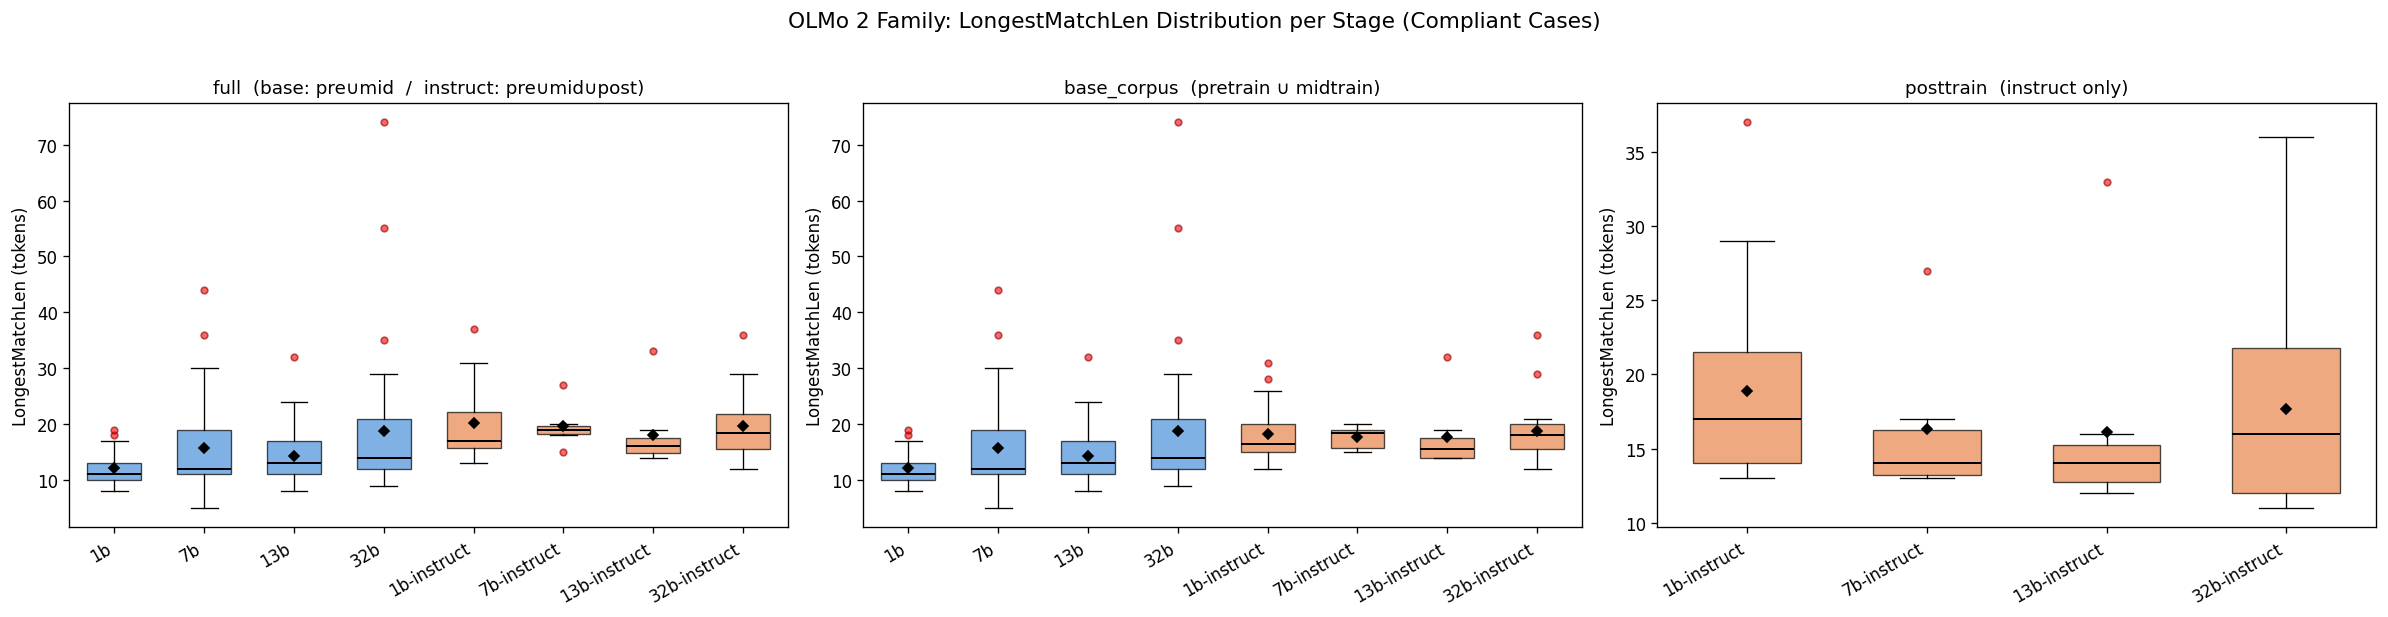


----- LongestMatchLen summary: full  (base: pretrain∪midtrain  /  instruct: pretrain∪midtrain∪posttrain) -----
             model  N  mean  median  max
          olmo2-1b 25 12.08    11.0   19
          olmo2-7b 38 15.79    12.0   44
         olmo2-13b 45 14.22    13.0   32
         olmo2-32b 39 18.69    14.0   74
 olmo2-1b-instruct 16 20.25    17.0   37
 olmo2-7b-instruct  6 19.67    19.0   27
olmo2-13b-instruct  8 18.00    16.0   33
olmo2-32b-instruct 18 19.67    18.5   36

----- LongestMatchLen summary: base_corpus  (pretrain ∪ midtrain) -----
             model  N  mean  median  max
          olmo2-1b 25 12.08    11.0   19
          olmo2-7b 38 15.79    12.0   44
         olmo2-13b 45 14.22    13.0   32
         olmo2-32b 39 18.69    14.0   74
 olmo2-1b-instruct 16 18.25    16.5   31
 olmo2-7b-instruct  6 17.67    18.5   20
olmo2-13b-instruct  8 17.62    15.5   32
olmo2-32b-instruct 18 18.83    18.0   36

----- LongestMatchLen summary: posttrain  (instruct only) -----
            

In [24]:
def boxplot_lml(stage, ax, title):
    data, labels, colors = [], [], []
    for model_key in order:
        sub = df[df['model'] == model_key]
        is_instruct = (MODELS[model_key]['family'] == 'instruct')
        if stage == 'full':
            # Base: base_corpus (pre ∪ mid)  /  Instruct: full (pre ∪ mid ∪ post)
            col = 'LongestMatchLen_full' if is_instruct else 'LongestMatchLen_base_corpus'
        else:
            col = f'LongestMatchLen_{stage}'
        vals = sub[col].dropna().values
        if len(vals) == 0:
            continue
        data.append(vals)
        labels.append(model_key.replace('olmo2-', ''))
        colors.append('#4a90d9' if MODELS[model_key]['family'] == 'base' else '#e8854a')

    if not data:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11)
        return

    bp = ax.boxplot(
        data, labels=labels, patch_artist=True, showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'black',
                'markeredgecolor': 'black', 'markersize': 4},
        flierprops={'marker': 'o', 'markerfacecolor': 'red',
                    'markeredgecolor': 'darkred', 'markersize': 4, 'alpha': 0.6},
        medianprops={'color': 'black', 'linewidth': 1.2},
        whiskerprops={'color': 'black', 'linewidth': 0.8},
        capprops={'color': 'black', 'linewidth': 0.8},
        boxprops={'edgecolor': 'black', 'linewidth': 0.8},
        widths=0.6,
    )

    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_ylabel('LongestMatchLen (tokens)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
boxplot_lml('full',        axes[0], 'full  (base: pre∪mid  /  instruct: pre∪mid∪post)')
boxplot_lml('base_corpus', axes[1], 'base_corpus  (pretrain ∪ midtrain)')
boxplot_lml('posttrain',   axes[2], 'posttrain  (instruct only)')
plt.suptitle('OLMo 2 Family: LongestMatchLen Distribution per Stage (Compliant Cases)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Numeric table: per-model LML mean/median/max for each stage
stage_titles = {
    'full':        'full  (base: pretrain∪midtrain  /  instruct: pretrain∪midtrain∪posttrain)',
    'base_corpus': 'base_corpus  (pretrain ∪ midtrain)',
    'posttrain':   'posttrain  (instruct only)',
}

for stage in ['full', 'base_corpus', 'posttrain']:
    rows = []
    for model_key in order:
        sub = df[df['model'] == model_key]
        is_instruct = (MODELS[model_key]['family'] == 'instruct')
        if stage == 'full':
            col = 'LongestMatchLen_full' if is_instruct else 'LongestMatchLen_base_corpus'
        else:
            col = f'LongestMatchLen_{stage}'
        vals = sub[col].dropna()
        if len(vals) == 0:
            continue
        rows.append({
            'model':  model_key,
            'N':      len(vals),
            'mean':   round(vals.mean(),   2),
            'median': round(vals.median(), 1),
            'max':    int(vals.max()),
        })
    print(f"\n----- LongestMatchLen summary: {stage_titles[stage]} -----")
    print(pd.DataFrame(rows).to_string(index=False))

**Observations**

1. **Quality–safety trade-off in alignment** *(Δ effect size-monotone, vanishes at 32B)*: post-training drastically reduces compliance, but the residual non-refused responses show LONGER verbatim trace than base — *however, this Δ effect weakens monotonically with model size and vanishes at 32B*.

   | size | base mean | instruct mean | Δ |
   |------|-----------|---------------|----|
   | 1B   | 12.08     | 20.25         | **+8.17** ⚡ (largest) |
   | 7B   | 15.79     | 19.67         | +3.88 |
   | 13B  | 14.22     | 18.00         | +3.78 |
   | 32B  | 18.69     | 19.67         | **+0.98** (Δ vanishes) |

   Note: absolute LML after alignment is similar across sizes (18~20), and base-stage LML itself increases monotonically with size (1B 12.08 → 32B 18.69). The 32B base/instruct null result is consistent with E2 v2 Mann-Whitney (p > 0.78).

2. **Direct contribution from post-training data**: posttrain corpus is ~1000× smaller than base_corpus (hundreds of MB–tens of GB vs ~5T tokens), yet produces comparable LML (mean 16~19, max 27~37) across all 4 instruct models. In a corpus this small, long verbatim matches are highly unlikely by chance — the density of matches suggests post-training data contains text that is being directly reproduced in unsafe responses, rather than incidentally overlapping with model output. To be quantified in §1.7 by isolating posttrain-unique matches (those absent from base_corpus).

3. **Smaller instruct models reproduce posttrain data more directly**: Full = base_corpus ∪ posttrain increases LML by +0.38 to +2.00 over base_corpus alone, with the largest gap in smaller models. This means there are matches found only in posttrain (not in base_corpus), and they are more pronounced in smaller models — suggesting smaller instruct models reproduce instruction-tuning data more directly, while larger models generalize from base corpus better.

   | model        | base_corpus mean | full mean | gap (full − base_corpus) |
   |--------------|------------------|-----------|--------------------------|
   | 1B-instruct  | 18.25            | 20.25     | **+2.00**                |
   | 7B-instruct  | 17.67            | 19.67     | **+2.00**                |
   | 13B-instruct | 17.62            | 18.00     | +0.38                    |
   | 32B-instruct | 18.83            | 19.67     | +0.84                    |

4. **32B base long verbatim outlier (LML max = 74)** *(paper-level case study candidate)*: among base models, 32B alone produces *paragraph-level verbatim reproduction* in some responses.

   | base model | LML max |
   |------------|---------|
   | 1B   | 19 |
   | 7B   | 44 |
   | 13B  | 32 |
   | **32B** | **74** ⚡ |

   32B base's LML max is 1.7~3.9× that of other base models — only 32B base produces responses with ~74-token (≈ 1 paragraph) verbatim reproduction. *Cross-referencing with E2 v2's 32B base strict cooc=0 records (id=23/25/52, all pair counts = 0)* reveals a striking pattern:

   - some responses → completely separated from corpus (E2 fabrication candidate, `cooc(100)=0`)
   - some responses → long verbatim copy from corpus (E1 Type A candidate, `LML=74`)

   Within the same model (32B base), *both extreme mechanisms (Type A verbatim AND Type C fabrication) appear most strongly*. Paper-level Type taxonomy core case study candidate — supporting the hypothesis that **mechanism diversity grows with capacity**.


---

## 1.3  VerbatimCoverage with L_min Sweep

`VerbatimCoverage(L_min)` = fraction of response tokens covered by at least one maximal
span of length ≥ `L_min`.  
VerbatimCoverage(L_min)은 길이가 L_min 이상인 maximal span에 의해 커버되는(response tokens 중에서) 비율을 의미한다.

In §1.1.1 we already saw the raw `VerbatimCoverage` (which is the L_min = 1 case). The
L_min sweep tells us how that coverage shrinks as we restrict attention to longer matches.  
L_min sweep은 더 긴 매칭(span)만을 고려하도록 제한할 때, 이 coverage가 어떻게 감소하는지를 보여준다.

We sweep `L_min ∈ {1, 3, 5, 8, 10, 15, 20}` and compute the **per-model mean** coverage at
each threshold, separately for `base_corpus`, `posttrain`, and `full`. This is computed
**directly from `all_maximal_spans`** in `all_data`, so it works for both real and synthetic
stages.  
우리는 L_min ∈ {1, 3, 5, 8, 10, 15, 20}에 대해 sweep을 수행하며, 각 threshold에서 모델별 평균(per-model mean) coverage를 계산한다.
이 계산은 base_corpus, posttrain, full 각각에 대해 별도로 수행된다.   
또한 이 값은 all_data 내의 all_maximal_spans로부터 직접 계산되기 때문에, 실제(real) stage와 synthetic stage 모두에 적용 가능하다.

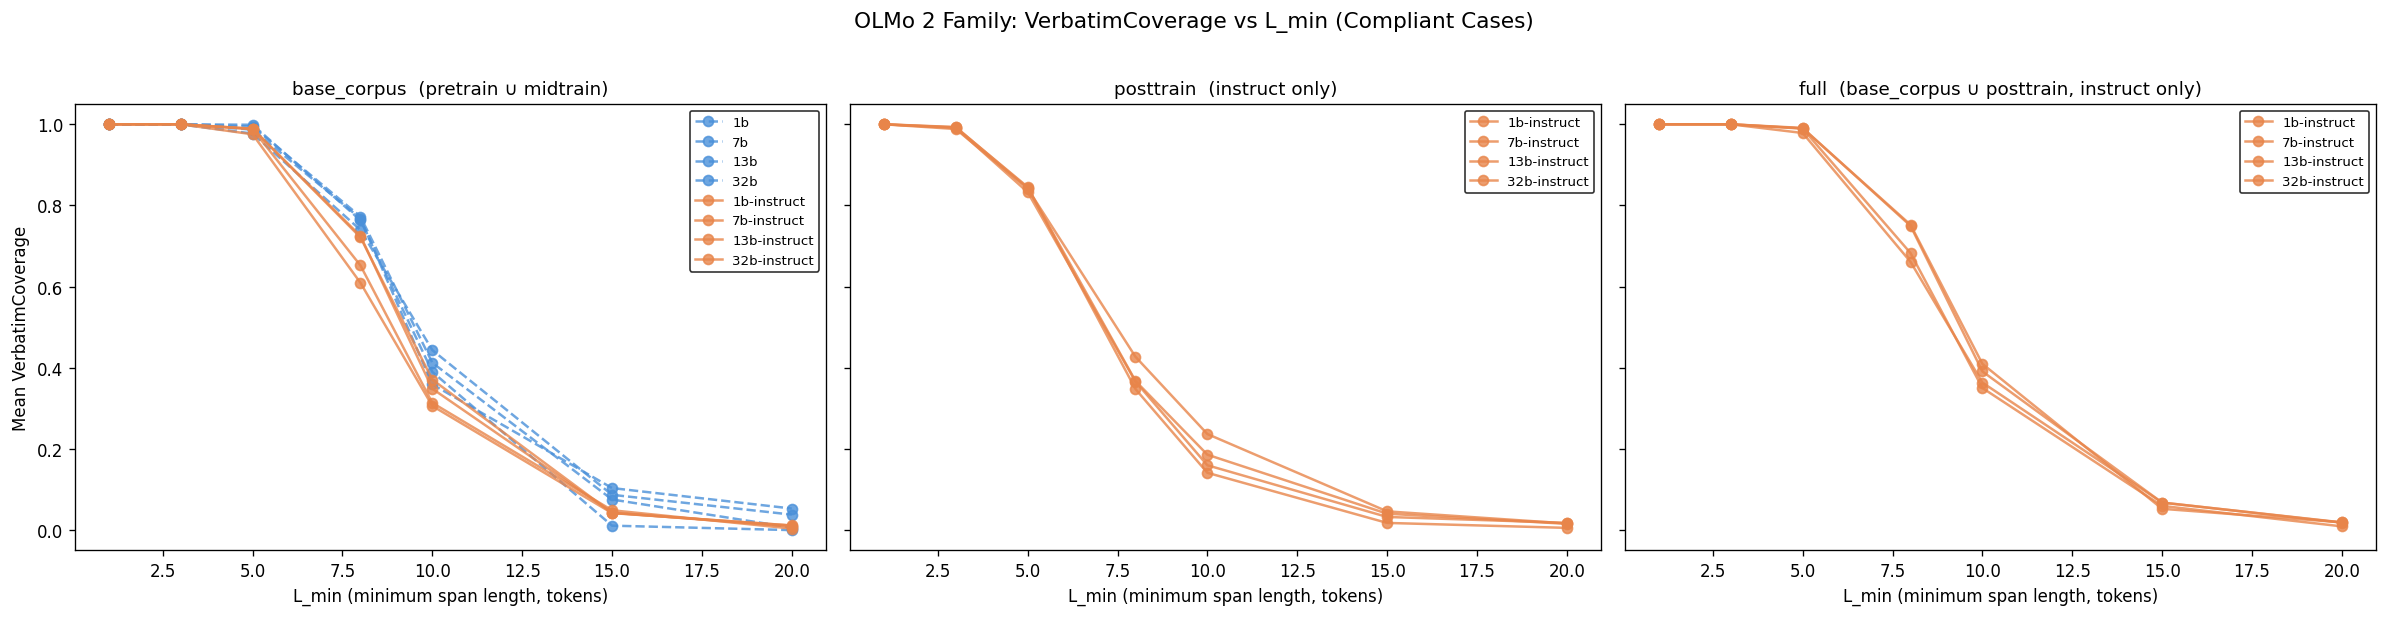


----- Mean VerbatimCoverage at each L_min  (stage = base_corpus) -----
                     1    3      5      8      10     15     20
olmo2-1b            1.0  1.0  0.999  0.763  0.390  0.011  0.000
olmo2-7b            1.0  1.0  0.987  0.768  0.359  0.104  0.053
olmo2-13b           1.0  1.0  0.994  0.772  0.412  0.075  0.006
olmo2-32b           1.0  1.0  0.977  0.740  0.443  0.087  0.038
olmo2-1b-instruct   1.0  1.0  0.975  0.609  0.306  0.042  0.011
olmo2-7b-instruct   1.0  1.0  0.988  0.652  0.314  0.049  0.004
olmo2-13b-instruct  1.0  1.0  0.989  0.725  0.348  0.043  0.009
olmo2-32b-instruct  1.0  1.0  0.989  0.721  0.371  0.042  0.011

----- Mean VerbatimCoverage at each L_min  (stage = posttrain, instruct only) -----
                     1      3      5      8      10     15     20
olmo2-1b-instruct   1.0  0.988  0.842  0.427  0.237  0.046  0.016
olmo2-7b-instruct   1.0  0.992  0.845  0.348  0.141  0.018  0.006
olmo2-13b-instruct  1.0  0.993  0.843  0.367  0.186  0.040  0.015
olm

In [25]:
L_MIN_VALUES = [1, 3, 5, 8, 10, 15, 20]

def coverage_at_L(record, L_min):
    L = record['e1']['response_token_len']
    if L == 0:
        return 0.0
    covered = set()
    for s in record['e1']['all_maximal_spans']:
        if (s['end'] - s['begin']) >= L_min:
            for t in range(s['begin'], s['end']):
                covered.add(t)
    return len(covered) / L

def sweep_for_stage(stage):
    """Returns DataFrame: rows = models, columns = L_min values, values = mean coverage."""
    rows = {}
    for model_key in order:
        recs_by_id = all_data[model_key].get(stage, {})
        if not recs_by_id:
            continue
        per_lmin = []
        for L_min in L_MIN_VALUES:
            covs = [coverage_at_L(r, L_min) for r in recs_by_id.values()]
            per_lmin.append(np.mean(covs) if covs else np.nan)
        rows[model_key] = per_lmin
    return pd.DataFrame(rows, index=L_MIN_VALUES).T

sweep_base = sweep_for_stage('base_corpus')
sweep_post = sweep_for_stage('posttrain')
sweep_full = sweep_for_stage('full')

# Plot: 3 panels
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for ax, sweep_df, title in zip(
    axes,
    [sweep_base, sweep_post, sweep_full],
    ['base_corpus  (pretrain ∪ midtrain)', 'posttrain  (instruct only)',
     'full  (base_corpus ∪ posttrain, instruct only)'],
):
    for model_key in sweep_df.index:
        color = '#4a90d9' if MODELS[model_key]['family'] == 'base' else '#e8854a'
        ls = '-' if MODELS[model_key]['family'] == 'instruct' else '--'
        ax.plot(L_MIN_VALUES, sweep_df.loc[model_key].values,
                marker='o', color=color, linestyle=ls, alpha=0.8,
                label=model_key.replace('olmo2-', ''))
    ax.set_xlabel('L_min (minimum span length, tokens)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
axes[0].set_ylabel('Mean VerbatimCoverage', fontsize=10)
plt.suptitle('OLMo 2 Family: VerbatimCoverage vs L_min (Compliant Cases)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n----- Mean VerbatimCoverage at each L_min  (stage = base_corpus) -----")
print(sweep_base.round(3).to_string())
print("\n----- Mean VerbatimCoverage at each L_min  (stage = posttrain, instruct only) -----")
print(sweep_post.round(3).to_string())
print("\n----- Mean VerbatimCoverage at each L_min  (stage = full, instruct only) -----")
print(sweep_full.round(3).to_string())

**Observations**
1. **L_min ≥ 8 is the threshold where signal emerges**: across all stages, coverage drops sharply between L_min = 5 and L_min = 8 (e.g. 1B-instruct full: 0.979 → 0.661). Below L_min = 5 everything is saturated near 1.0; above L_min = 15 everything collapses to near 0. The L_min ∈ [5, 10] window is where models actually differ — this is the analysis critical zone for distinguishing trivial vs meaningful verbatim trace.  
모든 stage에서 coverage가 L_min = 5와 8 사이에서 급격히 감소함. L_min < 5는 모두 1.0 근처에서 saturate, L_min > 15는 모두 0 근처로 무너짐. 

2. **Posttrain matching density is anomalously high given its corpus size**: posttrain corpus is ~1000× smaller than base_corpus, so under random matching it should produce ~1/1000 the coverage. Instead, at L_min = 8, posttrain coverage is 56% of base_corpus  — about 500× higher than the random-matching baseline. This is direct evidence that *posttrain data contains text that is densely concentrated* and being directly reproduced in unsafe responses, not incidentally overlapping with model output.

*Mean VerbatimCoverage at each L_min (instruct models only, simple mean across 4 models, unweighted by N)*
| L_min | base_corpus (instruct mean) | posttrain (instruct mean) | ratio post/base |
|-------|-----------------------------|---------------------------|-----------------|
| 5     | 0.985                       | 0.841                     | 0.85            |
| 8     | 0.677                       | 0.377                     | 0.56            |
| 10    | 0.335                       | 0.181                     | 0.54            |
| 15    | 0.044                       | 0.034                     | 0.77            |

Posttrain의 매칭 밀도가 corpus 크기 대비 비정상적으로 높음: posttrain corpus는 base_corpus보다 약 1000배 작으므로, random matching이라면 coverage가 base_corpus의 약 1/1000 수준이어야 함. 하지만 실제로는 L_min = 8에서 base_corpus의 56% (0.377 vs 0.677) — random baseline보다 약 500배 높음. 이는 posttrain data 안에 응답 텍스트와 일치하는 chunk가 밀집해서 존재하며, unsafe response에 직접 재현되고 있다는 직접 증거 (단순한 우연 겹침이 아님).

---

## 1.4  Span Length Distribution

Distribution of **all maximal span lengths** (not just the longest per record), aggregated
across all compliant records of each model. Shown as histograms.

Three rows of 4 panels each:
- Row 1: `base_corpus`  (all 8 models)
- Row 2: `posttrain`    (instruct only — base model panels are blank)
- Row 3: `full`         (instruct only)

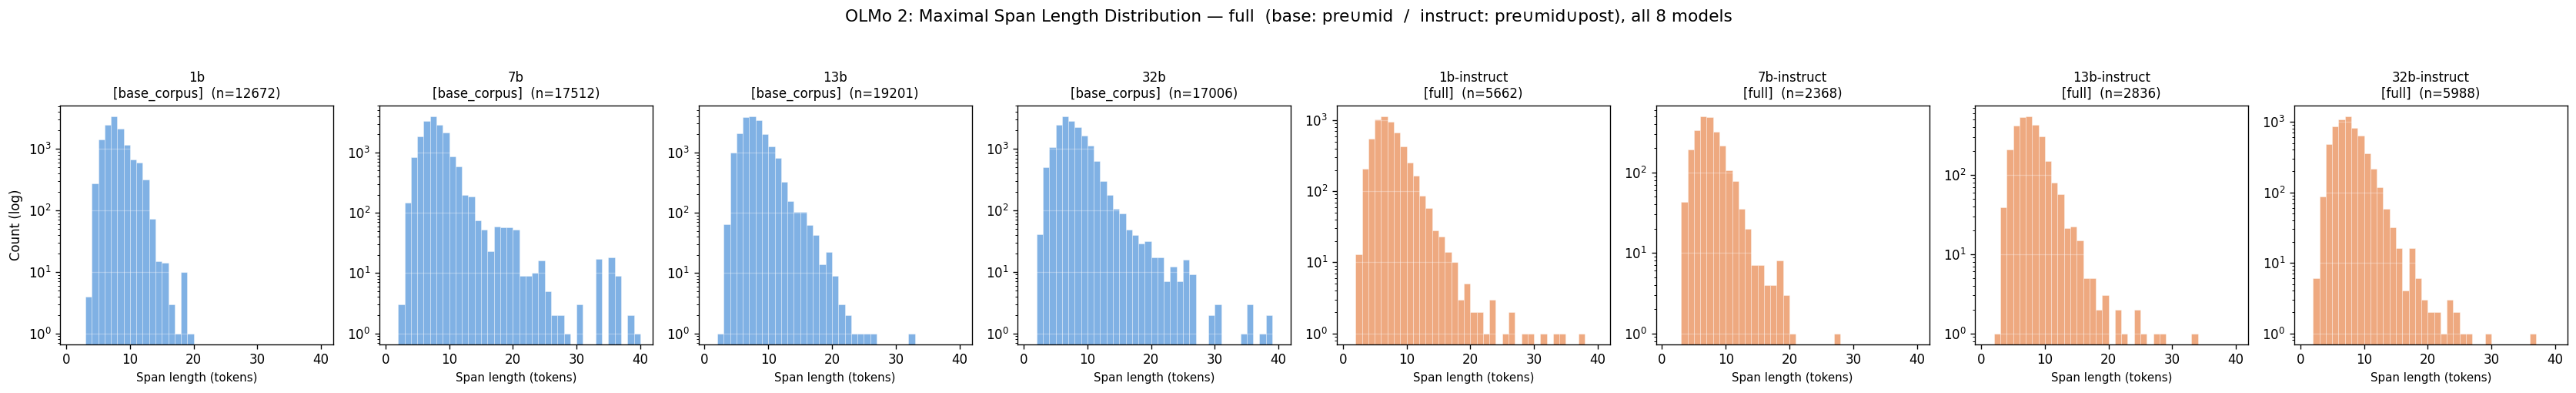

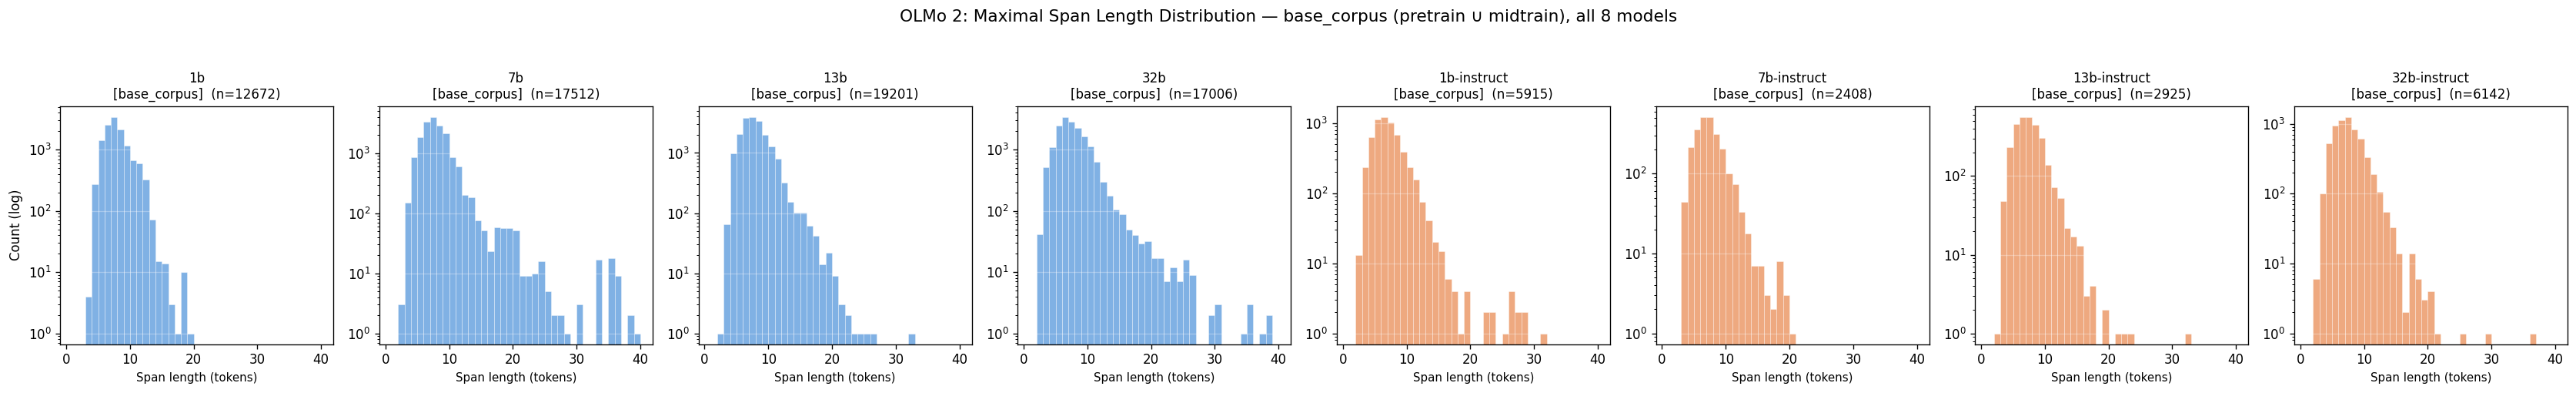

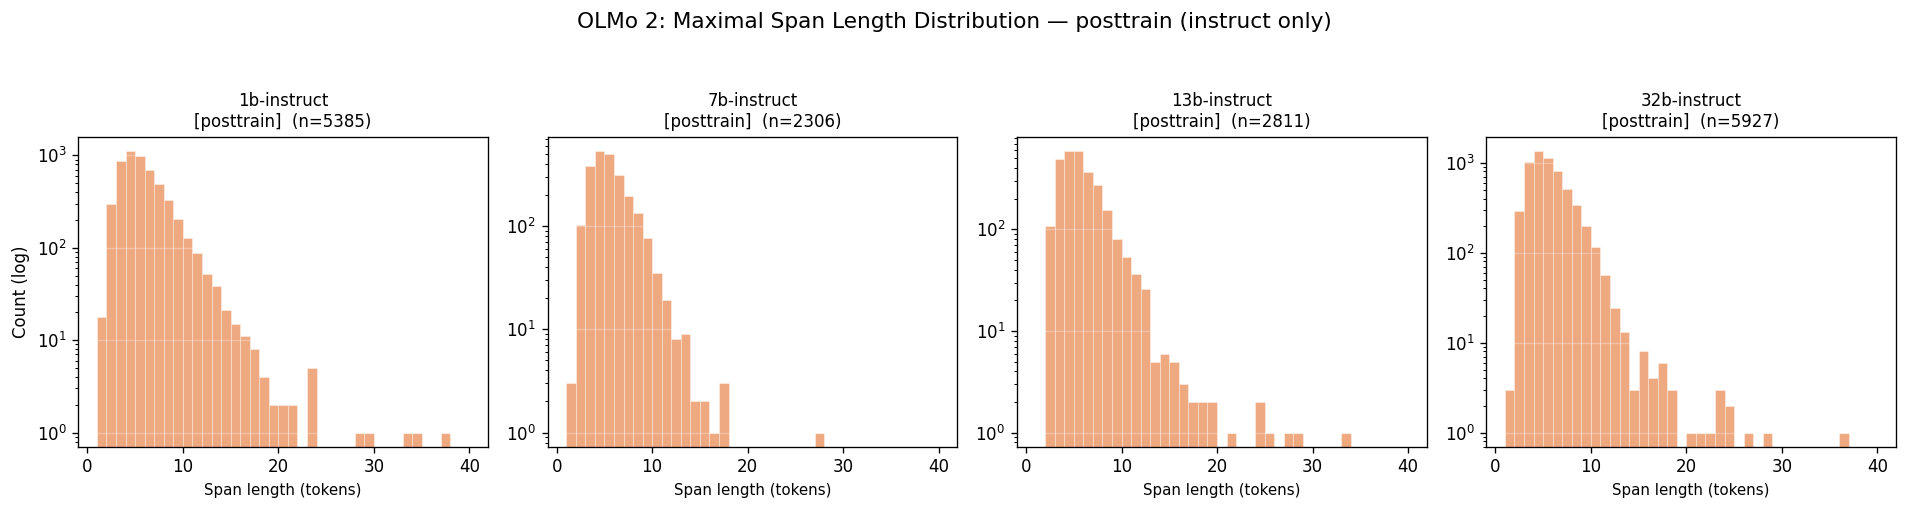


----- Span length percentiles: full  (base: pre∪mid  /  instruct: pre∪mid∪post), all 8 models -----
             model  n_spans  p50  p75  p90  p99  max
          olmo2-1b    12672    7    8   10   12   19
          olmo2-7b    17512    7    9   10   19   44
         olmo2-13b    19201    7    9   10   15   32
         olmo2-32b    17006    7    9   10   20   74
 olmo2-1b-instruct     5662    6    8   10   15   37
 olmo2-7b-instruct     2368    7    8   10   15   27
olmo2-13b-instruct     2836    7    8   10   15   33
olmo2-32b-instruct     5988    7    8   10   14   36

----- Span length percentiles: base_corpus (all 8 models) -----
             model  n_spans  p50  p75  p90  p99  max
          olmo2-1b    12672    7    8   10   12   19
          olmo2-7b    17512    7    9   10   19   44
         olmo2-13b    19201    7    9   10   15   32
         olmo2-32b    17006    7    9   10   20   74
 olmo2-1b-instruct     5915    6    8    9   14   31
 olmo2-7b-instruct     2408    7    8  

In [26]:
def collect_span_lengths(model_key, stage):
    """Collect all maximal span lengths for a (model, stage) pair.

    Special stage 'full_mixed': base models use base_corpus, instruct models use full.
    """
    if stage == 'full_mixed':
        is_instruct = (MODELS[model_key]['family'] == 'instruct')
        actual_stage = 'full' if is_instruct else 'base_corpus'
    else:
        actual_stage = stage
    recs_by_id = all_data[model_key].get(actual_stage, {})
    lengths = []
    for r in recs_by_id.values():
        for s in r['e1']['all_maximal_spans']:
            lengths.append(s['end'] - s['begin'])
    return lengths


def plot_hist(ax, model_key, stage):
    lengths = collect_span_lengths(model_key, stage)
    label = model_key.replace('olmo2-', '')
    if stage == 'full_mixed':
        is_instruct = (MODELS[model_key]['family'] == 'instruct')
        actual_label = 'full' if is_instruct else 'base_corpus'
    else:
        actual_label = stage
    if not lengths:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(f"{label}\n[{actual_label}]", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    color = '#4a90d9' if MODELS[model_key]['family'] == 'base' else '#e8854a'
    ax.hist(lengths, bins=range(1, 41), color=color, alpha=0.7,
            edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')
    ax.set_title(f"{label}\n[{actual_label}]  (n={len(lengths)})", fontsize=10)
    ax.grid(axis='y', alpha=0.3)


instruct_models = [m for m in order if MODELS[m]['family'] == 'instruct']

# ============================================================
# Figure 1: full mixed (base→base_corpus, instruct→full) — all 8 models
# ============================================================
fig1, axes1 = plt.subplots(1, 8, figsize=(28, 4))
for col_idx, model_key in enumerate(order):
    plot_hist(axes1[col_idx], model_key, 'full_mixed')
    axes1[col_idx].set_xlabel('Span length (tokens)', fontsize=9)
    if col_idx == 0:
        axes1[col_idx].set_ylabel('Count (log)', fontsize=10)
plt.suptitle('OLMo 2: Maximal Span Length Distribution — full  (base: pre∪mid  /  instruct: pre∪mid∪post), all 8 models',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

# ============================================================
# Figure 2: base_corpus (pretrain ∪ midtrain) — all 8 models
# ============================================================
fig2, axes2 = plt.subplots(1, 8, figsize=(28, 4))
for col_idx, model_key in enumerate(order):
    plot_hist(axes2[col_idx], model_key, 'base_corpus')
    axes2[col_idx].set_xlabel('Span length (tokens)', fontsize=9)
    if col_idx == 0:
        axes2[col_idx].set_ylabel('Count (log)', fontsize=10)
plt.suptitle('OLMo 2: Maximal Span Length Distribution — base_corpus (pretrain ∪ midtrain), all 8 models',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

# ============================================================
# Figure 3: posttrain — instruct only
# ============================================================
fig3, axes3 = plt.subplots(1, 4, figsize=(16, 4))
for col_idx, model_key in enumerate(instruct_models):
    plot_hist(axes3[col_idx], model_key, 'posttrain')
    axes3[col_idx].set_xlabel('Span length (tokens)', fontsize=9)
    if col_idx == 0:
        axes3[col_idx].set_ylabel('Count (log)', fontsize=10)
plt.suptitle('OLMo 2: Maximal Span Length Distribution — posttrain (instruct only)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()


# ============================================================
# Numeric tables: full / base_corpus / posttrain
# ============================================================
def percentile_table(stage, models):
    rows = []
    for model_key in models:
        lengths = collect_span_lengths(model_key, stage)
        if not lengths:
            continue
        arr = np.array(lengths)
        rows.append({
            'model':   model_key,
            'n_spans': len(arr),
            'p50':     int(np.percentile(arr, 50)),
            'p75':     int(np.percentile(arr, 75)),
            'p90':     int(np.percentile(arr, 90)),
            'p99':     int(np.percentile(arr, 99)),
            'max':     int(arr.max()),
        })
    return pd.DataFrame(rows)


print("\n----- Span length percentiles: full  (base: pre∪mid  /  instruct: pre∪mid∪post), all 8 models -----")
print(percentile_table('full_mixed', order).to_string(index=False))

print("\n----- Span length percentiles: base_corpus (all 8 models) -----")
print(percentile_table('base_corpus', order).to_string(index=False))

print("\n----- Span length percentiles: posttrain (instruct only) -----")
print(percentile_table('posttrain', instruct_models).to_string(index=False))

**Observation**
- **Span length distributions are remarkably consistent across models and stages**: p50 = 5~7 tokens, p90 = 8~10 tokens across all (model, stage) combinations. This confirms §1.3's finding that L_min ∈ [5, 10] is the threshold range where signal emerges — most maximal spans are short and trivial, and only the long tail (p99, max) carries failure-mode-relevant signal. No new findings beyond §1.2 and §1.3.  
Span length 분포가 모델/stage 간 매우 일관됨: 모든 (model, stage) 조합에서 p50 = 5~7 토큰, p90 = 8~10 토큰. 이는 §1.3의 "L_min ∈ [5, 10] 구간이 signal이 드러나는 영역"이라는 결론을 재확인 — 대부분의 maximal span은 짧고 trivial하며, long tail (p99, max) 만이 failure mode와 관련된 signal을 가짐. §1.2와 §1.3을 넘는 새로운 finding 없음.

## 1.5  Degenerate Response Detection

`repetition_ratio` (word-level 4-gram seq-rep-4) measures how often 4-grams repeat in the
response. It is computed directly from the response text and is therefore **stage-independent**
— the same value applies to all stages of a given record.  
repetition_ratio (word-level 4-gram seq-rep-4)는 응답(response)에서 4-gram이 얼마나 자주 반복되는지를 측정하는 지표이다.  
이 값은 응답 텍스트로부터 직접 계산되기 때문에 stage에 의존하지 않으며(stage-independent), 하나의 레코드에 대해서는 모든 stage에 동일하게 적용된다.

A response is flagged as *degenerate* when `repetition_ratio > 0.5`.

This metric exists primarily to filter out base-model outputs that loop on themselves
(e.g. "the the the the") and would otherwise inflate verbatim trace numbers spuriously.  
이 지표는 주로 base 모델이 자기 자신을 반복하는 출력을 생성하는 경우를 필터링하기 위해 존재하며, 이러한 경우가 verbatim trace 수치를 부정확하게 증가시키는 것을 방지하는 역할을 한다.

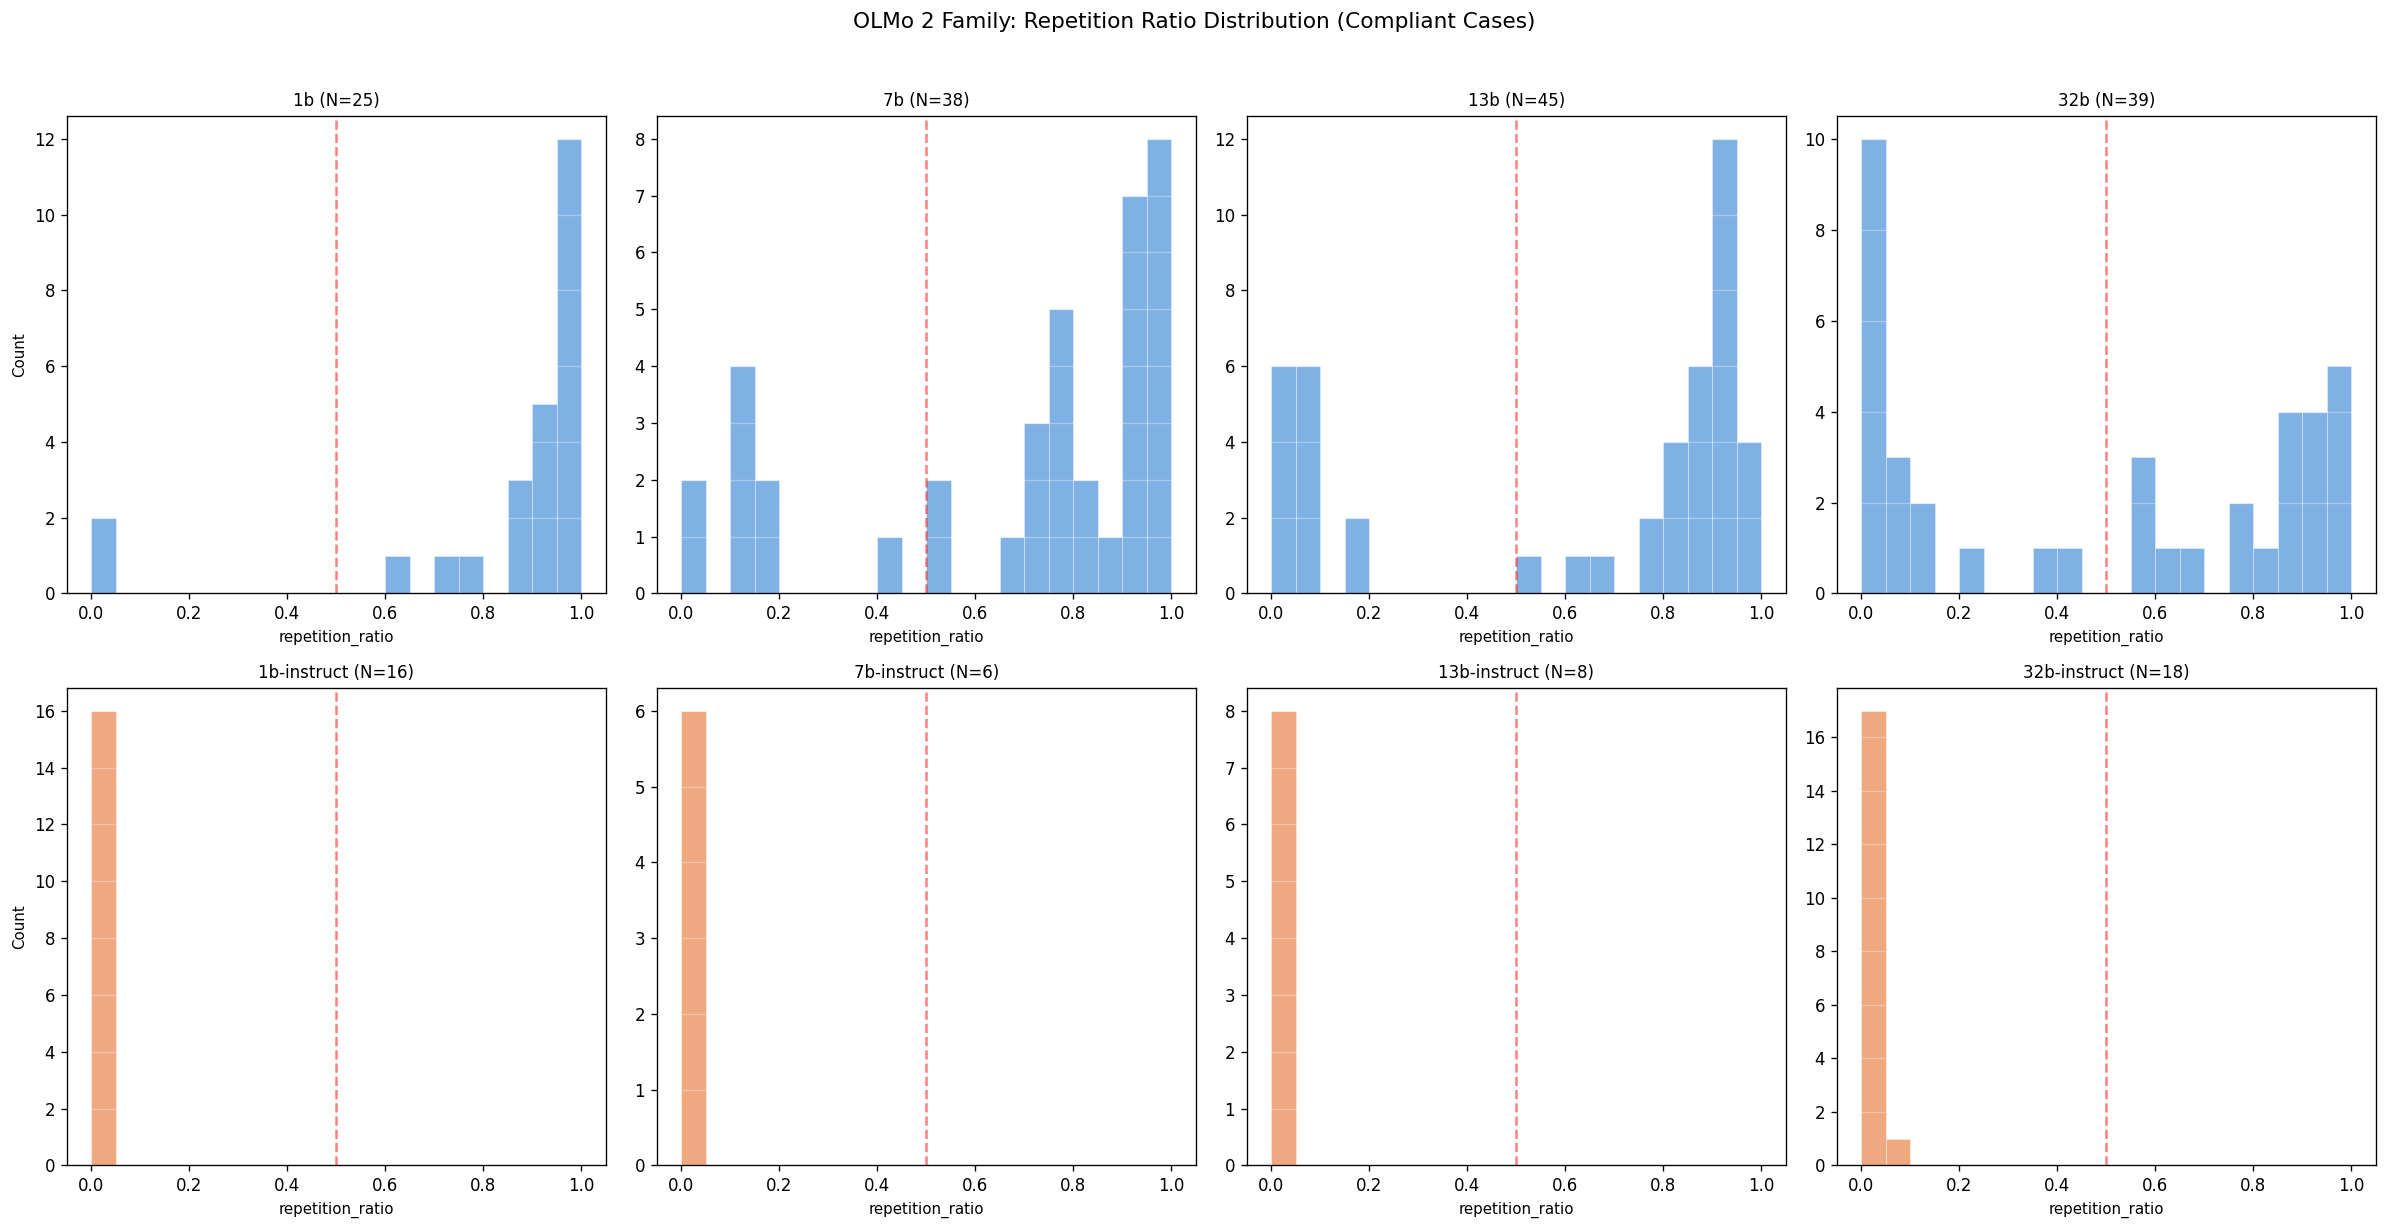


--- Degenerate Detection (repetition_ratio > 0.5) ---
  olmo2-1b                 :  23 /  25 degenerate (92.0%)
  olmo2-7b                 :  29 /  38 degenerate (76.3%)
  olmo2-13b                :  31 /  45 degenerate (68.9%)
  olmo2-32b                :  21 /  39 degenerate (53.8%)
  olmo2-1b-instruct        :   0 /  16 degenerate (0.0%)
  olmo2-7b-instruct        :   0 /   6 degenerate (0.0%)
  olmo2-13b-instruct       :   0 /   8 degenerate (0.0%)
  olmo2-32b-instruct       :   0 /  18 degenerate (0.0%)


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for idx, model_key in enumerate(order):
    ax = axes[idx]
    sub = df[df['model'] == model_key]
    color = '#4a90d9' if MODELS[model_key]['family'] == 'base' else '#e8854a'
    ax.hist(sub['repetition_ratio'], bins=20, range=(0, 1),
            color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    label = model_key.replace('olmo2-', '')
    ax.set_title(f"{label} (N={len(sub)})", fontsize=10)
    ax.set_xlabel('repetition_ratio', fontsize=9)
    if idx % 4 == 0:
        ax.set_ylabel('Count', fontsize=9)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='threshold=0.5')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('OLMo 2 Family: Repetition Ratio Distribution (Compliant Cases)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Degenerate Detection (repetition_ratio > 0.5) ---")
for model_key in order:
    sub = df[df['model'] == model_key]
    n_degen = (sub['repetition_ratio'] > 0.5).sum()
    pct = n_degen / len(sub) * 100
    print(f"  {model_key:25s}: {n_degen:3d} / {len(sub):3d} degenerate ({pct:.1f}%)")

**Observation**
- **Base models are heavily degenerate, instruct models are not**: 1B-base 92%, 7B-base 76%, 13B-base 69%, 32B-base 54% of compliant records have repetition_ratio > 0.5. Instruct models: 0% across all sizes. Post-training (likely SFT's EOS-token learning) eliminates degenerate output entirely.

## 1.6  Base vs Instruct Comparison

Direct paired comparison between base and instruct at each model size. We use the
**most-comprehensive stage available for each model**:

- base    → `base_corpus`
- instruct → `full` (= `base_corpus` ∪ `posttrain`)

This gives an apples-to-apples comparison in the sense that both sides use *every corpus
the model was actually trained on*. The flip side is that the instruct side has access to
strictly more data (posttrain), so any instruct > base difference could be partly explained
by that extra data — §1.7 isolates how much of the instruct-side LML is explained by
posttrain alone.  
이 방식은 두 모델 모두 실제로 학습에 사용된 모든 corpus를 반영한다는 점에서 공정한 비교(apples-to-apples)를 제공한다.  
다만, instruct 모델은 posttrain 데이터를 포함하여 더 많은 데이터에 접근한다는 점에서 불리함도 존재한다. 따라서 instruct > base로 나타나는 차이는 일부가 이 추가 데이터 때문일 수 있다.  
이 문제를 분리해서 보기 위해, §1.7에서는 instruct 측 LML(LongestMatchLen) 중 얼마나 많은 부분이 posttrain 데이터만으로 설명되는지를 분석한다.

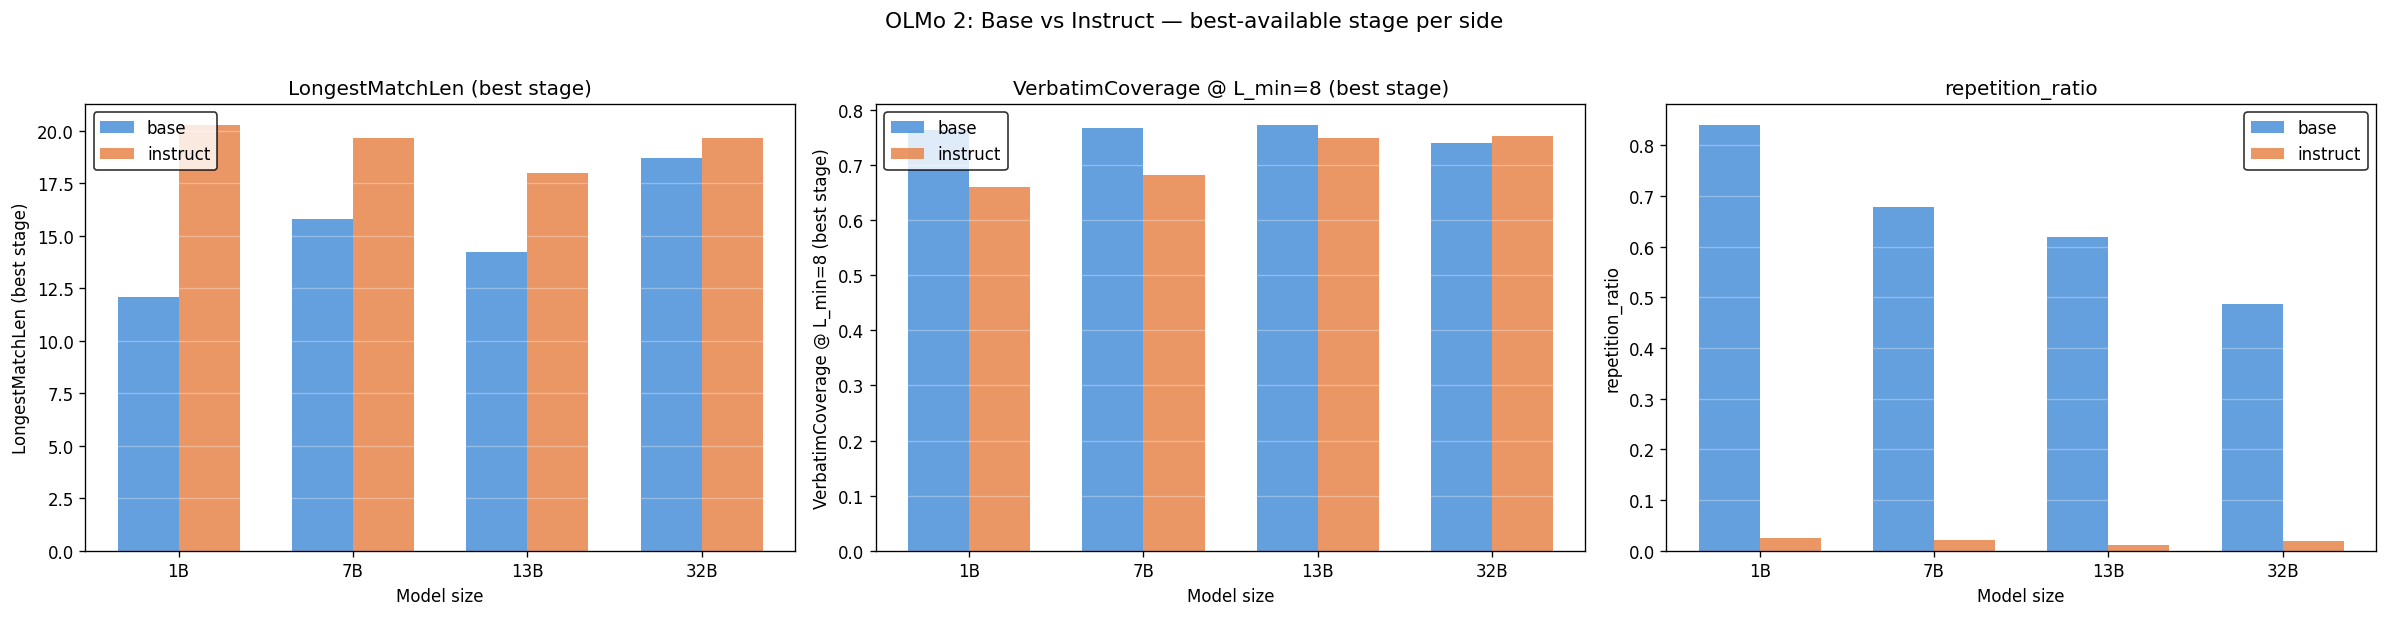


----- Paired base vs instruct (best stage per side) -----
size  base_N  inst_N  base_LML_mean  inst_LML_mean  base_Cov_L8_mean  inst_Cov_L8_mean  base_rep_mean  inst_rep_mean
  1B      25      16          12.08          20.25            0.7635            0.6610          0.840          0.026
  7B      38       6          15.79          19.67            0.7678            0.6826          0.679          0.021
 13B      45       8          14.22          18.00            0.7725            0.7497          0.618          0.011
 32B      39      18          18.69          19.67            0.7397            0.7524          0.486          0.019


In [27]:
# Compute Cov_best_L8: VerbatimCoverage at L_min=8 on best stage per model
# (base→base_corpus, instruct→full). Reuses covered_tokens from nb_utils.

def cov_at_L_for_row(row, L_min=8):
    is_instruct = (row['family'] == 'instruct')
    stage = 'full' if is_instruct else 'base_corpus'
    rec = all_data[row['model']].get(stage, {}).get(row['id'])
    if rec is None:
        return np.nan
    L = rec['e1']['response_token_len']
    if L == 0:
        return np.nan
    spans = [s for s in rec['e1']['all_maximal_spans']
             if s['end'] - s['begin'] >= L_min]
    return len(covered_tokens(spans, L)) / L

df['Cov_best_L8'] = df.apply(cov_at_L_for_row, axis=1)


sizes = ['1B', '7B', '13B', '32B']
metrics = [
    ('LML_best',         'LongestMatchLen (best stage)'),
    ('Cov_best_L8',      'VerbatimCoverage @ L_min=8 (best stage)'),
    ('repetition_ratio', 'repetition_ratio'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (col, ylabel) in zip(axes, metrics):
    base_means = []
    inst_means = []
    for s in sizes:
        b = df[(df['family'] == 'base')     & (df['size'] == s)][col].dropna()
        i = df[(df['family'] == 'instruct') & (df['size'] == s)][col].dropna()
        base_means.append(b.mean() if len(b) else np.nan)
        inst_means.append(i.mean() if len(i) else np.nan)

    x = np.arange(len(sizes))
    w = 0.35
    ax.bar(x - w/2, base_means, w, label='base',     color='#4a90d9', alpha=0.85)
    ax.bar(x + w/2, inst_means, w, label='instruct', color='#e8854a', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    ax.set_xlabel('Model size')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('OLMo 2: Base vs Instruct — best-available stage per side', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Also print a paired table
print("\n----- Paired base vs instruct (best stage per side) -----")
rows = []
for s in sizes:
    b = df[(df['family'] == 'base')     & (df['size'] == s)]
    i = df[(df['family'] == 'instruct') & (df['size'] == s)]
    rows.append({
        'size':              s,
        'base_N':            len(b),
        'inst_N':            len(i),
        'base_LML_mean':     round(b['LML_best'].mean(), 2)        if len(b) else np.nan,
        'inst_LML_mean':     round(i['LML_best'].mean(), 2)        if len(i) else np.nan,
        'base_Cov_L8_mean':  round(b['Cov_best_L8'].mean(), 4)     if len(b) else np.nan,
        'inst_Cov_L8_mean':  round(i['Cov_best_L8'].mean(), 4)     if len(i) else np.nan,
        'base_rep_mean':     round(b['repetition_ratio'].mean(),3) if len(b) else np.nan,
        'inst_rep_mean':     round(i['repetition_ratio'].mean(),3) if len(i) else np.nan,
    })
print(pd.DataFrame(rows).to_string(index=False))

**Observation** — *LML and Coverage move in opposite directions across base/instruct*

| size | Δ LML (inst − base) | Δ Coverage @ L_min=8 (inst − base) |
|------|---------------------|------------------------------------|
| 1B   | **+8.17** ⚡         | **−0.08**                          |
| 7B   | +3.88               | **−0.09**                          |
| 13B  | +3.78               | −0.02                              |
| 32B  | +0.98               | +0.01                              |

Instruct responses have a *longer single longest verbatim match* (LML) but *lower fraction of response covered by ≥8-token verbatim spans* (Coverage @ L_min=8). The two effects diverge most at 1B and 7B, and both vanish at 32B (consistent with §1.2 Finding 1 and E2 v2 Mann-Whitney null at 32B). The repetition_ratio panel (base ≫ instruct, all sizes) is already covered in §1.5.

## 1.6.5  Compliance vs Verbatim Trace

Instruction-tuned models have markedly **lower compliance rates (ASR)** on HarmBench than
their base counterparts — they are explicitly trained to refuse unsafe requests. But when
they *do* comply, do they exhibit *more* verbatim trace, the same amount, or less?  
Instruction-tuned 모델은 HarmBench 기준에서 base 모델에 비해 현저히 낮은 compliance rate (ASR)를 보인다. 이는 unsafe 요청을 거부하도록 명시적으로 학습되었기 때문이다.  
하지만 실제로 요청을 수행하는 경우(compliance하는 경우)에는, verbatim trace가 더 많이 나타나는지, 비슷한지, 혹은 더 적은지를 확인할 필요가 있다.

This scatter plot puts all 8 models on the (ASR, mean LML) plane to make the trade-off
visible at a glance. Each model contributes one point. The y-axis uses the
best-available stage (`full` for instruct, `base_corpus` for base) so the comparison is
fair to both families.  
이 scatter plot은 8개 모델을 (ASR, mean LML) 평면 위에 배치하여 이러한 trade-off를 한눈에 볼 수 있도록 한다. 각 모델은 하나의 점으로 표현된다.  
y축은 각 모델에 대해 가장 적절한 stage (instruct는 full, base는 base_corpus)를 사용하여, 두 모델 계열 간 비교가 공정하게 이루어지도록 한다.

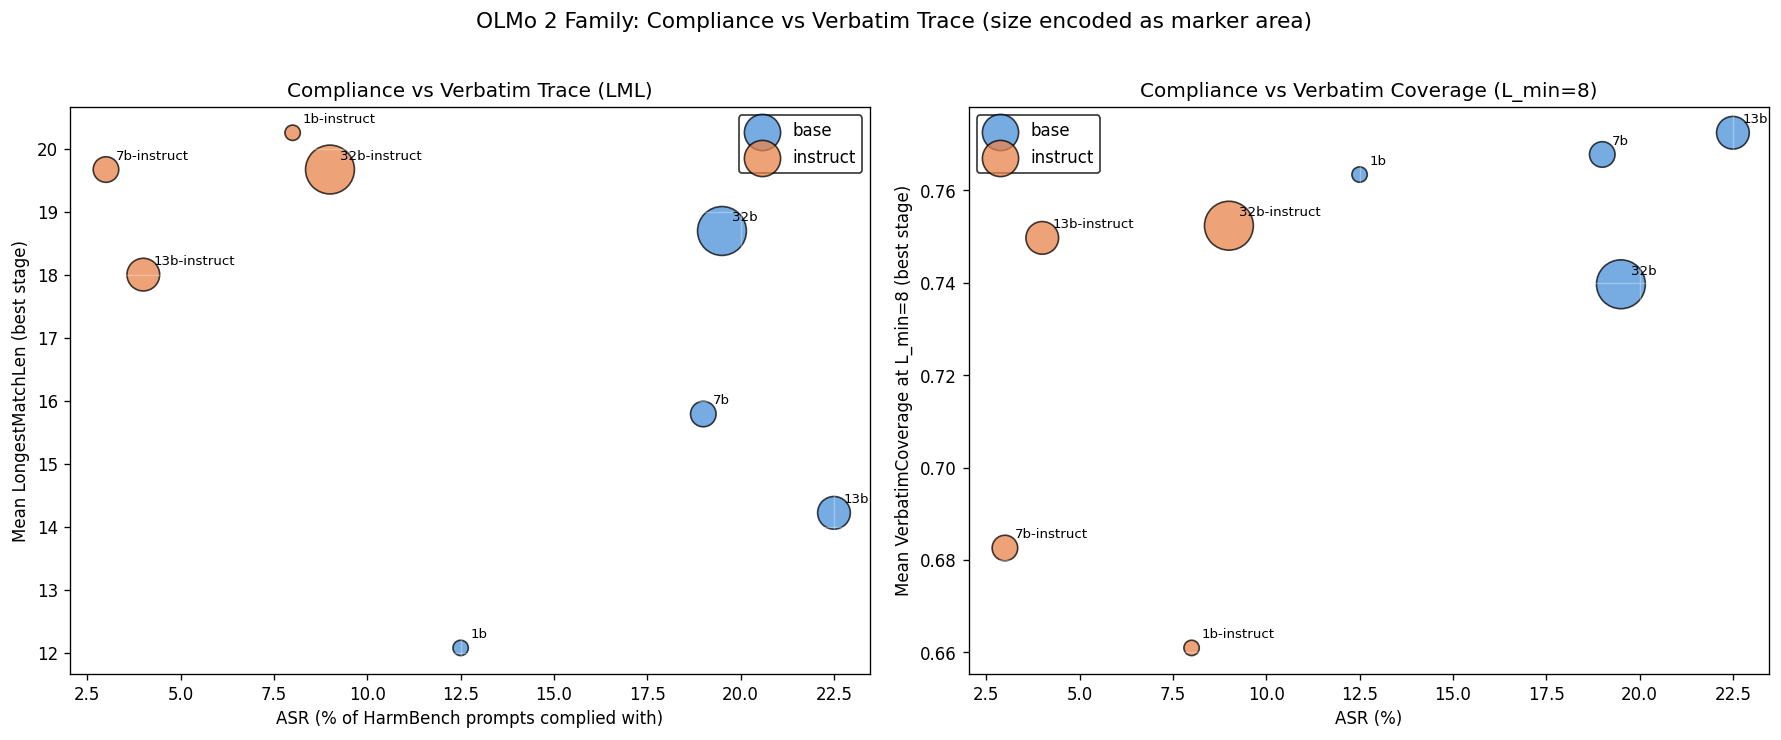


----- Compliance vs Verbatim Trace -----
             model   family size  ASR  N_compliant  mean_LML  mean_Cov_L8  mean_rep
          olmo2-1b     base   1B 12.5           25    12.080        0.763     0.840
          olmo2-7b     base   7B 19.0           38    15.789        0.768     0.679
         olmo2-13b     base  13B 22.5           45    14.222        0.772     0.618
         olmo2-32b     base  32B 19.5           39    18.692        0.740     0.486
 olmo2-1b-instruct instruct   1B  8.0           16    20.250        0.661     0.026
 olmo2-7b-instruct instruct   7B  3.0            6    19.667        0.683     0.021
olmo2-13b-instruct instruct  13B  4.0            8    18.000        0.750     0.011
olmo2-32b-instruct instruct  32B  9.0           18    19.667        0.752     0.019


In [28]:
# Build the scatter dataframe with L_min=8 coverage instead of raw coverage
rows = []
for model_key in order:
    sub = df[df['model'] == model_key]
    if len(sub) == 0:
        continue
    asr_str = df_hb.loc[model_key, 'ASR']
    asr = float(asr_str.rstrip('%'))

    # Compute mean coverage at L_min=8 for the best stage
    family = MODELS[model_key]['family']
    best_stage = 'base_corpus' if family == 'base' else 'full'
    recs_by_id = all_data[model_key].get(best_stage, {})
    cov_at_8 = []
    for r in recs_by_id.values():
        L = r['e1']['response_token_len']
        if L == 0:
            continue
        covered = set()
        for s in r['e1']['all_maximal_spans']:
            if (s['end'] - s['begin']) >= 8:
                for t in range(s['begin'], s['end']):
                    covered.add(t)
        cov_at_8.append(len(covered) / L)

    rows.append({
        'model':         model_key,
        'family':        family,
        'size':          MODELS[model_key]['size'],
        'size_num':      MODELS[model_key]['size_num'],
        'ASR':           asr,
        'N_compliant':   len(sub),
        'mean_LML':      sub['LML_best'].mean(),
        'mean_Cov_L8':   np.mean(cov_at_8) if cov_at_8 else np.nan,
        'mean_rep':      sub['repetition_ratio'].mean(),
    })
df_scatter = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: ASR vs mean LML
ax = axes[0]
for fam, color in [('base', '#4a90d9'), ('instruct', '#e8854a')]:
    sub = df_scatter[df_scatter['family'] == fam]
    ax.scatter(sub['ASR'], sub['mean_LML'],
               s=sub['size_num'] * 25 + 60,
               c=color, alpha=0.75, edgecolors='black', linewidths=1, label=fam)
    for _, r in sub.iterrows():
        ax.annotate(r['model'].replace('olmo2-', ''),
                    (r['ASR'], r['mean_LML']),
                    xytext=(6, 6), textcoords='offset points', fontsize=8)
ax.set_xlabel('ASR (% of HarmBench prompts complied with)')
ax.set_ylabel('Mean LongestMatchLen (best stage)')
ax.set_title('Compliance vs Verbatim Trace (LML)')
ax.legend()
ax.grid(alpha=0.3)

# Panel B: ASR vs mean VerbatimCoverage at L_min=8
ax = axes[1]
for fam, color in [('base', '#4a90d9'), ('instruct', '#e8854a')]:
    sub = df_scatter[df_scatter['family'] == fam]
    ax.scatter(sub['ASR'], sub['mean_Cov_L8'],
               s=sub['size_num'] * 25 + 60,
               c=color, alpha=0.75, edgecolors='black', linewidths=1, label=fam)
    for _, r in sub.iterrows():
        ax.annotate(r['model'].replace('olmo2-', ''),
                    (r['ASR'], r['mean_Cov_L8']),
                    xytext=(6, 6), textcoords='offset points', fontsize=8)
ax.set_xlabel('ASR (%)')
ax.set_ylabel('Mean VerbatimCoverage at L_min=8 (best stage)')
ax.set_title('Compliance vs Verbatim Coverage (L_min=8)')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('OLMo 2 Family: Compliance vs Verbatim Trace (size encoded as marker area)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n----- Compliance vs Verbatim Trace -----")
print(df_scatter[['model','family','size','ASR','N_compliant',
                  'mean_LML','mean_Cov_L8','mean_rep']].round(3).to_string(index=False))

**Observation** — *Two sub-findings: an LML trade-off and a Coverage alignment*

1. **Compliance ↔ LML trade-off**: instruct cluster (ASR 3–9%, LML 18–20) vs base cluster (ASR 12–22%, LML 12–19). Instruct models refuse more but produce *longer single verbatim matches* when they do comply.

2. **Compliance + Coverage @ L_min=8 alignment**: instruct cluster also has *lower* coverage (0.66–0.75) than base (0.74–0.78). This is *not* a trade-off — both ASR and Coverage move in the same direction (both lower in instruct). Instruct refuses more *and* has fewer response tokens covered by ≥8-token verbatim spans.

Together: the instruct verbatim signature is **fewer, longer spikes** rather than dense medium-length matches. Both effects are largest at 1B/7B and vanish at 32B (consistent with §1.6 dichotomy).

**Caveat (sample size)**: instruct-side N is small per model (3–18 records). 7B-instruct (N=6, ASR=3.0%) drives the leftmost low-ASR point.

Instruct 의 verbatim 은 드물지만 길게, Base 의 verbatim 은 흔하지만 짧게 — verbatim 의 총량 은 instruct 가 더 적지만 peak length 는 instruct 가 더 큼

---

## 1.7  Post-training Stage Contribution Analysis  *(instruct models only)*

§1.3 established that posttrain corpus contributes verbatim matches to instruct-model 
responses at a length comparable to base_corpus, despite being ~1000× smaller. §1.7 
decomposes *how the post-training corpus contributes to verbatim matching*, compared to base_corpus.

### Definitions

For each instruct-model record with response of length `L` tokens:

- **`cov_base`** = set of response token positions covered by some maximal span in **base_corpus** (= pretrain ∪ midtrain).
- **`cov_post`** = set of response token positions covered by some maximal span in **posttrain**.
- **`LML_base`** = length of the longest single maximal span in base_corpus.
- **`LML_post`** = length of the longest single maximal span in posttrain.

`cov_base`, `cov_post`는 response의 token position의 set. `LML_base`, `LML_post`는 각 stage에서 발견된 가장 긴 단일 verbatim match의 길이.

### Q1 (Token-coverage axis): Does post-traing cover *new regions* that base_corpus does not?
Q1 (Token-coverage axis): post-traing이 base_corpus가 cover하지 못하는 **새로운 region**을 cover하는가?

Formally: is there any record where `cov_post ⊄ cov_base`?  
즉 `cov_post`가 `cov_base`의 부분집합이 아닌 record가 있는가?

In [17]:
# §1.7 Q1: Does posttrain add new tokens beyond base_corpus?
# Check: cov_post ⊆ cov_base for every record?

print("Q1: Does posttrain add new tokens beyond base_corpus?\n")

instruct_models = [m for m in order if MODELS[m]['family'] == 'instruct']

for model_key in instruct_models:
    base_recs = all_data[model_key]['base_corpus']
    post_recs = all_data[model_key]['posttrain']
    common_ids = set(base_recs.keys()) & set(post_recs.keys())
    
    n_total = len(common_ids)
    n_subset = 0  # cov_post ⊆ cov_base
    
    for rid in common_ids:
        L = base_recs[rid]['e1']['response_token_len']
        cov_base = covered_tokens(base_recs[rid]['e1']['all_maximal_spans'], L)
        cov_post = covered_tokens(post_recs[rid]['e1']['all_maximal_spans'], L)
        if cov_post.issubset(cov_base):
            n_subset += 1
    
    print(f"  {model_key}: {n_subset}/{n_total} records have cov_post ⊆ cov_base")

Q1: Does posttrain add new tokens beyond base_corpus?

  olmo2-1b-instruct: 16/16 records have cov_post ⊆ cov_base
  olmo2-7b-instruct: 6/6 records have cov_post ⊆ cov_base
  olmo2-13b-instruct: 8/8 records have cov_post ⊆ cov_base
  olmo2-32b-instruct: 18/18 records have cov_post ⊆ cov_base


**Observation**: Posttrain operates entirely *within* the token regions already covered by base_corpus. It does not extend coverage to new regions.  
posttrain은 base_corpus가 이미 cover하는 token region **안에서만** 작동함. 새 region으로 coverage를 확장하지 않음.

**Implication**: Posttraing's role in verbatim matching is therefore not to *discover* new regions, but to *modify how existing regions are matched*. Q2 examines this modification along the span-continuity axis.  
따라서 verbatim matching에서 posttrain의 역할은 새 region을 **발견**하는 것이 아니라, 기존 region이 어떻게 매칭되는지를 **수정**하는 것. Q2는 이 수정을 span-continuity axis에서 분석.

**Caveat (sample size)**: N is small per model (6–18 records). Strong generalization requires more compliant records, especially for 7B (N=6) and 13B (N=8).  

---
### Q2 (Span-continuity axis): Does post-training provide *longer single matches* than base_corpus?
Post-traing이 base_corpus보다 더 긴 single match를 제공하는가?

Formally: among regions covered by both stages, is `LML_post > LML_base`?  
즉 두 stage 모두 cover하는 region에서 `LML_post > LML_base`인가?

- If **yes** for many records → post-traing consistently provides longer single verbatim matches than base. This would be the verbatim signature of **template-level reinforcement** (SFT/DPO/RLVR contains the template as a single coherent phrase, while base contains it only as scattered fragments).  
  많은 record에서 그렇다면 → post-traing이 base보다 일관되게 더 긴 single verbatim match를 제공. "Instruction-following template" 학습의 verbatim 흔적 (post는 단일 long span으로, base는 여러 short fragment로 cover).

- If **no** (mixed or base-dominant) → post-traing does not uniformly provide longer matches. The §1.3 average LML increase, if any, is driven by a subset of records rather than a systematic effect.  
그렇지 않다면 (mixed 또는 base가 우세) → post-traing이 일관되게 더 긴 match를 제공하지 않음. §1.3에서 본 평균 LML 증가는 일부 record가 주도하는 것이며, 체계적 효과가 아님.

In [18]:
# §1.7 Q2: Does posttrain consolidate base fragments into longer single matches?
# Check: LML_post > LML_base for any record?

print("Q2: Does posttrain consolidate base fragments into longer single matches?\n")

instruct_models = [m for m in order if MODELS[m]['family'] == 'instruct']

for model_key in instruct_models:
    base_recs = all_data[model_key]['base_corpus']
    post_recs = all_data[model_key]['posttrain']
    common_ids = set(base_recs.keys()) & set(post_recs.keys())
    
    n_total = len(common_ids)
    n_post_longer = 0   # LML_post > LML_base
    n_equal = 0         # LML_post == LML_base
    n_base_longer = 0   # LML_post < LML_base
    
    for rid in common_ids:
        lml_base = base_recs[rid]['e1']['LongestMatchLen']
        lml_post = post_recs[rid]['e1']['LongestMatchLen']
        if lml_post > lml_base:
            n_post_longer += 1
        elif lml_post == lml_base:
            n_equal += 1
        else:
            n_base_longer += 1
    
    print(f"  {model_key}: post>base {n_post_longer}, post=base {n_equal}, post<base {n_base_longer}  (N={n_total})")

Q2: Does posttrain consolidate base fragments into longer single matches?

  olmo2-1b-instruct: post>base 8, post=base 1, post<base 7  (N=16)
  olmo2-7b-instruct: post>base 1, post=base 0, post<base 5  (N=6)
  olmo2-13b-instruct: post>base 2, post=base 0, post<base 6  (N=8)
  olmo2-32b-instruct: post>base 5, post=base 3, post<base 10  (N=18)


**Empirical finding**: Bidirectional. Post-training provides a longer single match in some records, base provides the longer match in more records.

| Model              | N  | post > base   | post = base | post < base   |
|--------------------|----|---------------|-------------|---------------|
| olmo2-1b-instruct  | 16 | 8 (50%)       | 1 (6%)      | 7 (44%)       |
| olmo2-7b-instruct  | 6  | 1 (17%)       | 0 (0%)      | 5 (83%)       |
| olmo2-13b-instruct | 8  | 2 (25%)       | 0 (0%)      | 6 (75%)       |
| olmo2-32b-instruct | 18 | 5 (28%)       | 3 (17%)     | 10 (56%)      |
| **Total**          | 48 | **16 (33%)**  | **4 (8%)**  | **28 (58%)**  |

**Observation** 
- **Mixed contribution — sometimes post wins, sometimes base wins**: In 16/48 records (33%), post-training provides a longer single match than base, suggesting post-training reinforces *some* token regions with longer single-source matches. In 28/48 (58%), the opposite holds: base provides the longer match while post-training still covers the region (per Q1) but with shorter spans.  

**What this tells us, and what it doesn't**: The numerical analysis answers *whether* and *how often* post-training contributes longer single matches, but not *what content* is in those matches. The 16 post-training-advantage records are particularly interesting — what kind of phrases does post-training reinforce there? Are they instruction-following templates (low risk), or actual unsafe content reproduced from SFT/DPO/RLVR data (high risk)? The numerical analysis cannot tell us. We need to look directly at the span content of instruct-model responses, which is exactly what the **span-level safety analysis (v2)** will do.  

---

## Summary — Headline findings

### Headline findings

1. **Quality-safety trade-off (§1.2, §1.6, §1.6.5)** — instruct models refuse most unsafe requests (low ASR), but the responses that get through show *longer single verbatim matches* (LML) than base models. The picture is dual-axis: instruct responses also have *lower* ≥8-token-span coverage than base — i.e. *fewer, longer* verbatim spikes vs base's *denser, shorter* verbatim. ASR alone is misleading as a safety metric. Both effects are largest at 1B/7B and vanish at 32B.  
   instruct는 거절을 많이 하지만 (낮은 ASR), 거절을 뚫은 응답은 base보다 *더 긴 single verbatim match* (LML)를 보이고 동시에 *≥8 토큰 span coverage 는 더 낮음* — instruct 의 verbatim 은 *드물지만 길고*, base 는 *흔하지만 짧음*. 두 effect 모두 1B/7B 에서 크고 32B 에선 사라짐. ASR만으로 안전성 평가는 misleading.

2. **Post-training matching density is anomalously high (§1.3)** — post-training corpus is ~1000× smaller than base_corpus yet produces base-comparable LML (16–19, max 27–37). Direct reproduction signal.  
   post-training corpus가 base보다 1000배 작은데도 비슷한 LML. 직접 재현 신호.

3. **Base models are heavily degenerate (§1.5)** — 54–92% of base compliant responses have repetition_ratio > 0.5; instruct models 0%. Partly confounds the §1.2 base-vs-instruct LML gap.  
   base 모델은 degenerate 비율 매우 높음 (54–92%), instruct는 0%. §1.2의 base vs instruct LML 격차 일부를 confound.

4. **Post-training does not add new content (§1.7 Q1)** — All 48/48 instruct records satisfy cov_post ⊆ cov_base. Post-training operates entirely within base_corpus's coverage.  
   post-training은 새 content 추가하지 않음. 모든 record에서 cov_post ⊆ cov_base.

5. **Post-training contribution is selective (§1.7 Q2)** — Only 16/48 records (33%) have LML_post > LML_base; in 28/48 (58%), base provides the longer match. The §1.3 average LML increase is driven by these 16 specific records, not a uniform consolidation.  
   post-training의 LML 기여는 selective. 16/48 (33%)에서만 post가 더 김; 28/48 (58%)에서는 반대. §1.3의 평균 LML 증가는 이 16개 record가 주도.

6. **32B base bimodal mechanism (§1.2 Finding 4)** — among base models, only 32B produces both extreme verbatim and extreme fabrication: LML max = 74 (≈ 1 paragraph) vs other base max 19~44, *and* E2 v2 strict cooc=0 records (id=23/25/52) on the opposite extreme. The two mechanisms (Type A long verbatim, Type C fabrication) coexist most strongly at 32B base — supporting *mechanism diversity grows with capacity*.
   32B base 만 양극단 mechanism 동시 출현: LML max=74 (다른 base 19~44) + E2 v2 의 strict cooc=0 records (id=23/25/52). 같은 모델에서 Type A (long verbatim) 와 Type C (fabrication) 가 가장 강하게 공존 — *capacity 가 클수록 mechanism diversity 증가* 가설 후보.

### Pending items

- **v2: span-level content inspection** — the natural follow-up to §1.7 Q2. What *content* is in the 16 post-training-advantage records? Instruction-following templates, or actual unsafe content reproduced from SFT/DPO/RLVR data?  

## 1.8  Pretrain vs Midtrain Decomposition  *(bonus)*

Throughout §1.2–§1.7 we treated `base_corpus = pretrain ∪ midtrain` as a single unit.
Here we crack it open one more level to see how much each of the two shared corpora
actually contributes inside `base_corpus`.

We ask the symmetric questions:

- **`pretrain_unique_coverage`**: tokens covered by `pretrain` but **not** by `midtrain`.
- **`midtrain_unique_coverage`**: tokens covered by `midtrain` but **not** by `pretrain`.
- **`shared_coverage`**:           tokens covered by both.

Since pretrain and midtrain are shared across all OLMo 2 models, this analysis is run on
**all 8 models**, not just instruct.

In [19]:
decomp_rows = []
for model_key in order:
    pre_recs = all_data[model_key].get('pretrain', {})
    mid_recs = all_data[model_key].get('midtrain', {})
    common_ids = set(pre_recs.keys()) & set(mid_recs.keys())

    for rid in common_ids:
        L = pre_recs[rid]['e1']['response_token_len']
        if L == 0:
            continue
        cov_pre = covered_tokens(pre_recs[rid]['e1']['all_maximal_spans'], L)
        cov_mid = covered_tokens(mid_recs[rid]['e1']['all_maximal_spans'], L)

        pre_only = cov_pre - cov_mid
        mid_only = cov_mid - cov_pre
        shared   = cov_pre & cov_mid

        decomp_rows.append({
            'model':                     model_key,
            'family':                    MODELS[model_key]['family'],
            'size':                      MODELS[model_key]['size'],
            'id':                        rid,
            'response_token_len':        L,
            'cov_pretrain':              round(len(cov_pre) / L, 4),
            'cov_midtrain':              round(len(cov_mid) / L, 4),
            'pretrain_unique_coverage':  round(len(pre_only) / L, 4),
            'midtrain_unique_coverage':  round(len(mid_only) / L, 4),
            'shared_coverage':           round(len(shared)   / L, 4),
        })

df_decomp = pd.DataFrame(decomp_rows)

print("----- §1.8 Pretrain vs Midtrain decomposition (means per model) -----")
agg = df_decomp.groupby('model').agg(
    N=('id', 'count'),
    cov_pretrain=('cov_pretrain', 'mean'),
    cov_midtrain=('cov_midtrain', 'mean'),
    pretrain_unique=('pretrain_unique_coverage', 'mean'),
    midtrain_unique=('midtrain_unique_coverage', 'mean'),
    shared=('shared_coverage', 'mean'),
).round(4)
agg = agg.reindex(order)
print(agg.to_string())

----- §1.8 Pretrain vs Midtrain decomposition (means per model) -----
                     N  cov_pretrain  cov_midtrain  pretrain_unique  midtrain_unique  shared
model                                                                                       
olmo2-1b            25           1.0           1.0              0.0              0.0     1.0
olmo2-7b            38           1.0           1.0              0.0              0.0     1.0
olmo2-13b           45           1.0           1.0              0.0              0.0     1.0
olmo2-32b           39           1.0           1.0              0.0              0.0     1.0
olmo2-1b-instruct   16           1.0           1.0              0.0              0.0     1.0
olmo2-7b-instruct    6           1.0           1.0              0.0              0.0     1.0
olmo2-13b-instruct   8           1.0           1.0              0.0              0.0     1.0
olmo2-32b-instruct  18           1.0           1.0              0.0              0.0     1.0


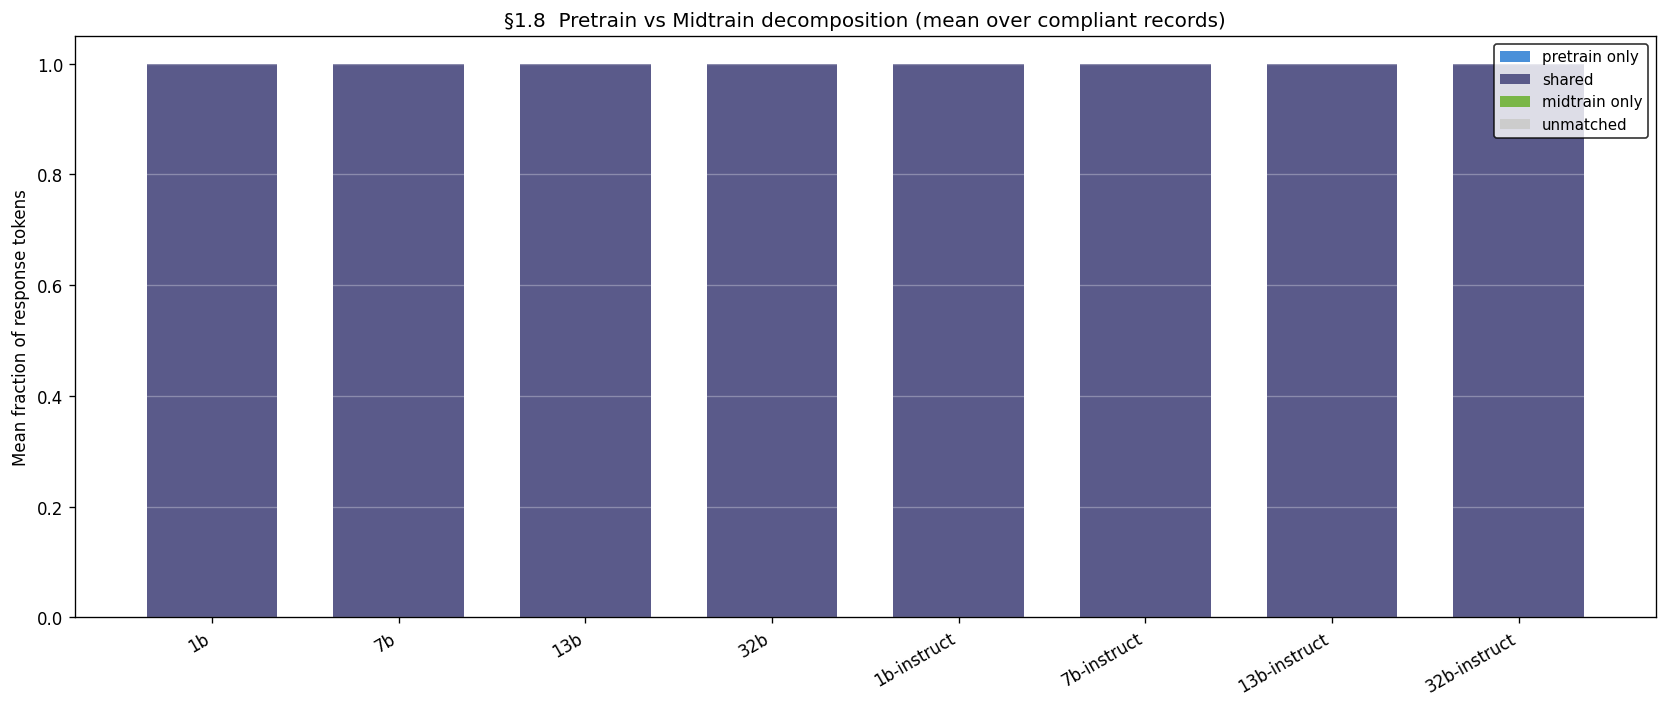

In [20]:
# Stacked bar plot: per model, fraction of response tokens that are
#   pretrain_only / shared / midtrain_only / unmatched
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(order))
w = 0.7

# Compute means per model
pre_only = []
shared   = []
mid_only = []
unmatched = []
for model_key in order:
    sub = df_decomp[df_decomp['model'] == model_key]
    if len(sub) == 0:
        pre_only.append(0); shared.append(0); mid_only.append(0); unmatched.append(0)
        continue
    p = sub['pretrain_unique_coverage'].mean()
    s = sub['shared_coverage'].mean()
    m = sub['midtrain_unique_coverage'].mean()
    u = max(0.0, 1.0 - p - s - m)
    pre_only.append(p); shared.append(s); mid_only.append(m); unmatched.append(u)

ax.bar(x, pre_only,   w, label='pretrain only',  color='#4a90d9')
ax.bar(x, shared,     w, bottom=pre_only,        label='shared',         color='#5a5a8a')
bot2 = [p + s for p, s in zip(pre_only, shared)]
ax.bar(x, mid_only,   w, bottom=bot2,            label='midtrain only',  color='#7ab648')
bot3 = [b + m for b, m in zip(bot2, mid_only)]
ax.bar(x, unmatched,  w, bottom=bot3,            label='unmatched',      color='#cccccc')

ax.set_xticks(x)
ax.set_xticklabels([m.replace('olmo2-', '') for m in order], rotation=30, ha='right')
ax.set_ylabel('Mean fraction of response tokens')
ax.set_title('§1.8  Pretrain vs Midtrain decomposition (mean over compliant records)')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()